#### Trajectory Optimisation

Here, the distances and times are optimised for each phase of the motion, so we can do speed = distance/time.

Import all the functions needed for simulation and wrinkliness calculations, from the 'Final_version_analysis' code.

In [8]:
import sys,os
notebook_dir = os.getcwd()  
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.append(parent_dir)
print(parent_dir)
from implementation.Cloth import Cloth 
from implementation.utils import createRectangularMesh
import time
import numpy as np

import polyscope as ps

import matplotlib.pyplot as plt

/Users/patriserratosa/Desktop/IRI/Thesis/Cloth Simulation Autocollisions (v2)/python_code


In [9]:
# -------------------------
# CLOTH TYPES
# -------------------------

CLOTH_TYPES = {

    "RL": {  # Rigid-Light
        "tol": 0.0075,
        "rho": 0.1,
        "delta": 0.1,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 0.1e-4,
        "str": 0.001e-4,
        "thck": 0.9,
    },

    "EL": {  # Elastic-Light
        "tol": 0.0075,
        "rho": 0.1,
        "delta": 0.1,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 10e-4,
        "str": 0.1e-4,
        "thck": 0.9,
    },

    "RH": {  # Rigid-Heavy
        "tol": 0.0075,
        "rho": 0.4,
        "delta": 0.4,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 0.1e-4,
        "str": 0.001e-4,
        "thck": 0.9,
    },

    "EH": {  # Elastic-Heavy
        "tol": 0.0075,
        "rho": 0.3,
        "delta": 0.3,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 10e-4,
        "str": 0.1e-4,
        "thck": 0.9,
    },

    "M": {  # In-between
        "tol": 0.0075,
        "rho": 0.2,
        "delta": 0.2,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 1e-4,
        "str": 0.01e-4,
        "thck": 0.9,
    },
}

# cloth_list = ["RL", "EL", "RH", "EH", "M"] # add more cloth types

In [10]:
def get_grasp_config(name, na):
    
    if name == "G1":
        return [0, na-1]
    
    elif name == "G2":
        return [0, 1, na, na+1, na-2, na-1, 2*na-2, 2*na-1]

    elif name == "G3":
        return (
            list(range(int((na/4)-2), int((na/4)+2)+1)) +
            list(range(int(3*(na/4)-2), int(3*(na/4)+2)+1))
        )
    
    elif name == "G4":
        return (
            list(range(int((na/4)-2), int((na/4)+2)+1)) + 
            list(range(int(3*(na/4)-2), int(3*(na/4)+2)+1)) + 
            list(range(int((na/4)-2+na), int((na/4)+2+na)+1)) + 
            list(range(int(3*(na/4)-2+na), int(3*(na/4)+2+na)+1))
        )
    
    elif name == "G5":
        return list(range(int((na/6)), int(5*(na/6))))

    elif name == "G6":
        return list(range(int((na/4))+1, int(3*(na/4))))

    else:
        raise ValueError("Unknown grasp configuration")

In [11]:
def create_initial_mesh(a=0.6, b=0.9, na=20): # limit nº of nodes to avoid long simulation times andmore stable results
    nb = int(na * (1 + a/b))
    
    X, T = createRectangularMesh(a=a, b=b, na=na, nb=nb, h=0.1)

    # Rotate -90° around X-axis
    theta = -np.pi / 2
    Rx = np.array([[1, 0, 0],
                   [0, np.cos(theta), -np.sin(theta)],
                   [0, np.sin(theta), np.cos(theta)]])
    X = X @ Rx.T

    # Raise above table
    X[:, 2] += 0.50

    return X, T, na, nb  # also return na, nb if needed

Function to compute metric.

In [12]:
# before calling this function, we need to do 
# V = Am @ history[-1] -> reconstruction of the final position of the mesh with more resolution using Am

def compute_wrinkle_sigma(V, k=20):
    """
    Compute surface variation (wrinkle intensity) per vertex.

    Parameters:
        V : (N,3) array of vertex positions
        k : number of nearest neighbors

    Returns:
        sigma : (N,) wrinkle intensity values
    """

    N = V.shape[0]
    sigma = np.zeros(N) # vector to store wrinkle intensity for each vertex

    for i in range(N): # loop over each vertex

        # Compute distances to all other points
        diff = V - V[i] # vector from v_i to all other vertices
        dist2 = np.sum(diff**2, axis=1) # squared Euclidean distancew

        # Get k nearest neighbors (excluding itself)
        idx = np.argsort(dist2)[1:k+1] # sort all distances and pick the k closest neighbors
        neighbors = V[idx]

        # Compute local mean to get centroid of neighborhood
        mean = np.mean(neighbors, axis=0)

        # Compute covariance matrix
        centered = neighbors - mean # center points around mean (shift neighbors to centroid)
        C = centered.T @ centered / k # covariance matrix of the neighborhood (3x3) captures local geometry around vertex i

        # Eigenvalues (symmetric matrix)
        eigvals = np.linalg.eigvalsh(C)
        # Sort them ascending 
        lambda1, lambda2, lambda3 = eigvals[2], eigvals[1], eigvals[0]

        # Surface variation = wrinkle intensity
        sigma[i] = lambda3 / (lambda1 + lambda2 + lambda3 + 1e-12)

    return sigma


In [13]:
def vertex_areas(V, F):
    """
    Compute approximate area around each vertex for a quad mesh.
    
    V: (n_verts, 3) vertex positions
    F: (n_faces, 4) quad faces (vertex indices)
    """
    areas = np.zeros(V.shape[0])
    
    # split quads into 2 triangles for area computation
    tris = np.vstack([F[:, [0,1,2]], F[:, [0,2,3]]])
    
    for tri in tris:
        v0, v1, v2 = V[tri[0]], V[tri[1]], V[tri[2]]
        tri_area = 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0))
        areas[tri] += tri_area / 3  # distribute equally to 3 vertices
        
    return areas

In [14]:
def compute_wrinkle_metric_area(V, F, sigma):
    areas = vertex_areas(V, F)
    
    # weighted mean
    W_global = np.sum(sigma * areas) / np.sum(areas)
    
    return W_global

1) Direction of movement within trajectory.

We are not keeping the trajectory constant anymore, so lambda knots cannot be fixed. These will be used to calculate lambda points.

In [15]:
# Original reference directions (unit vectors)
# These define the DIRECTION of each phase, not the distances
dir_back = np.array([0.0, 1.0, 0.0])  # Back motion: positive Y direction
dir_forward = np.array([0.0, -1.0, 0.0])  # Forward motion: negative Y
dir_diagonal = np.array([0.0, -1.0, -1.0])  # Diagonal: down and forward
dir_diagonal = dir_diagonal / np.linalg.norm(dir_diagonal)  # Normalize

# Fixed: You want the 3rd coordinate (Z) to go down the same distance always
# Distance from the point where motion starts (after stabilization) and surface
# If the case when cloth started lower, then the Z will be smaller because cloth is closer to surface
total_initial_down = 0.0 # set it to 0 if we don't want to start by touching table!
# the -0.93 is according to size of cloth -> CHANGE IT WHEN CLOTH SIZE CHANGES!!
FIXED_Z_DROP = -0.93 + total_initial_down # Fixed downward distance for diagonal phase
print(f'Fixed Z Drop: {FIXED_Z_DROP}')


Fixed Z Drop: -0.93


2) Function that gives the displacement from the starting point to that phase lambda so far, along the trajectory.

It gives the position of the cloth at each end of phase and the 4 lambda points wrt the new distances, which won't be constant.

In [16]:
def update_path_geometry(phase_distances):
    """
    Update the path geometry based on optimized distances.
    
    Args:
        phase_distances: [d_back, d_forward, d_diagonal] in meters
    
    Returns:
        d_back, d_forward, d_end: Updated displacement vectors
        lam_pts: Updated lambda parameterization
    """
    # Phase 1: Back motion (direction only)
    d_back = dir_back * phase_distances[0]
    
    # Phase 2: Forward motion (direction only)
    d_forward = d_back + dir_forward * phase_distances[1]
    
    # Phase 3: Diagonal motion
    remaining_distance = phase_distances[2]
    
    dz = FIXED_Z_DROP
    dy = -np.sqrt(max(0, remaining_distance**2 - dz**2))  # Negative for forward motion
    
    d_end = d_forward + np.array([0.0, dy, dz])
    
    print(f"\nUpdated path geometry:")
    print(f"  Phase 1 (back): {d_back} (distance: {phase_distances[0]:.3f}m)")
    print(f"  Phase 2 (forward): {d_forward} (distance: {phase_distances[1]:.3f}m)")
    print(f"  Phase 3 (diagonal): {d_end} (distance: {phase_distances[2]:.3f}m)")
    
    # Update lambda parameterization based on new distances
    L1 = phase_distances[0]
    L2 = phase_distances[1]
    L3 = phase_distances[2]
    L_total = L1 + L2 + L3
    
    lam_a = L1 / L_total
    lam_b = (L1 + L2) / L_total
    lam_pts = [0.0, lam_a, lam_b, 1.0]
    
    print(f"  Lambda points: {[f'{l:.4f}' for l in lam_pts]}")
    
    return d_back, d_forward, d_end, lam_pts


3. Create the path of the trajectory, to get the position of the cloth for each lambda step.

In [17]:
def create_linear_path_function(d_back, d_forward, d_end, lam_pts):
    """
    Create a linear interpolation function for the path.
    Returns a function that takes lam and returns position.
    """
    # Store the knot points for linear interpolation
    positions = np.array([
        [0.0, 0.0, 0.0],                       # λ=0
        [d_back[0], d_back[1], d_back[2]],     # λ=lam_a
        [d_forward[0], d_forward[1], d_forward[2]], # λ=lam_b
        [d_end[0], d_end[1], d_end[2]]         # λ=1.0
    ])
    
    def linear_position(lam):
        """Linear interpolation between knot points."""
        # Clamp lam to [0, 1]
        lam = max(0.0, min(1.0, lam))
        
        # Find which segment lam falls into
        for i in range(len(lam_pts)-1):
            if lam_pts[i] <= lam <= lam_pts[i+1]:
                # Linear interpolation between positions[i] and positions[i+1]
                if lam_pts[i+1] - lam_pts[i] > 0:
                    t = (lam - lam_pts[i]) / (lam_pts[i+1] - lam_pts[i])
                else:
                    t = 0
                return positions[i] + t * (positions[i+1] - positions[i])
        return positions[-1]  # Return last point if lam=1.0
    
    return linear_position

4. Linear interpolation for the trajectory definition.

In [18]:
# Get actual position from the lambda position within trajectory
linear_position_func = None
current_lam_pts = None

def get_position_at_lambda(lam):
    """Get the position at a given lambda using linear interpolation."""
    if linear_position_func is not None:
        return linear_position_func(lam)
    # Fallback (should not happen if called correctly)
    return np.array([0.0, 0.0, 0.0])

5. Function to generate the trajectory wrt distances and times per phase.

It uses linear path interpolation and PCHIP speed interpolation, to give the trajectory of the nodes (positions of nodes during the motion), the speeds at each lambda step and the lambda sequence progressing from 0.0 to 1.0.

In [19]:
from scipy.interpolate import PchipInterpolator

def generate_trajectory(phase_distances, phase_times, dt, min_speed=0.01, max_steps=5000):
    """
    Generate trajectory with LINEAR path interpolation but PCHIP speed interpolation.
    """
    global current_lam_pts, linear_position_func

    n_phases = len(phase_distances)

    # Update geometry based on new distances
    d_back, d_forward, d_end, lam_pts = update_path_geometry(phase_distances)
    current_lam_pts = lam_pts
    
    # Create LINEAR path interpolation function
    linear_position_func = create_linear_path_function(d_back, d_forward, d_end, lam_pts)

    # Calculate total λ range for each phase
    lam_ranges = []
    for i in range(n_phases):
        lam_range = lam_pts[i+1] - lam_pts[i]
        lam_ranges.append(lam_range)
    
    # Calculate speeds in λ/s for each phase (for PCHIP speed interpolation)
    lam_speeds = [0.0]  # speed at lam = 0
    for i in range(n_phases):
        if phase_times[i] > 0:
            v = lam_ranges[i] / phase_times[i]
        else:
            v = 0
        lam_speeds.append(v)
    
    # define phase change knots
    lam_a = lam_pts[1]
    lam_b = lam_pts[2]
    # λ knots and corresponding speeds
    lam_knots = [0.0,  lam_a*0.5, lam_b, lam_b + (1- lam_b)*0.5, 1.0]
    # lam_knots = [0.0,  lam_a*0.75, lam_b*0.75, (1- lam_b)*0.5, 1.0]
    speed_knots = [0.0, lam_speeds[1], lam_speeds[2], lam_speeds[3], 0.0]
    print(f'Lambda knots: {lam_knots}')

    # Create smooth speed interpolator using PCHIP (smooth acceleration)
    try:
        v_interp = PchipInterpolator(lam_knots, speed_knots)
    except:
        # Fallback to linear if PCHIP fails
        v_interp = lambda lam: np.interp(lam, lam_knots, speed_knots)
    
    # Generate smooth λ sequence (with smooth speeds)
    lam_seq = [0.0]
    current_lam = 0.0
    step = 0
    
    while current_lam < 1.0 and step < max_steps:
        lam_clamped = min(max(current_lam, lam_knots[0]), lam_knots[-1])
        v = v_interp(lam_clamped)
        if min_speed > 0:
            v = max(v, min_speed)
        current_lam += v * dt
        
        if current_lam > 1.0:
            current_lam = 1.0
        
        lam_seq.append(current_lam)
        step += 1
    
    # Convert λ sequence to positions using LINEAR path interpolation
    trajectory = [get_position_at_lambda(lam) for lam in lam_seq]
    
    return trajectory, lam_speeds, lam_seq

Speeds are constant for each segment, no interpolation done between knot points.

In [20]:
def generate_trajectory(phase_distances, phase_times, dt, min_speed=0.01):
    
    d_back, d_forward, d_end, lam_pts = update_path_geometry(phase_distances)
    linear_position_func = create_linear_path_function(d_back, d_forward, d_end, lam_pts)
    
    # Velocidad constante por fase (sin suavizado entre fases)
    lam_speeds = []
    for i in range(3):
        lam_range = lam_pts[i+1] - lam_pts[i]
        lam_speeds.append(lam_range / phase_times[i])
    
    # Generar secuencia lambda con velocidad constante por fase
    lam_seq = [0.0]
    current_lam = 0.0
    
    while current_lam < 1.0:
        # Determinar en qué fase estamos
        phase = 0
        for i in range(3):
            if current_lam >= lam_pts[i]:
                phase = i
        
        v = max(lam_speeds[phase], min_speed)
        current_lam += v * dt
        current_lam = min(current_lam, 1.0)
        lam_seq.append(current_lam)
    
    trajectory = [linear_position_func(lam) for lam in lam_seq]
    return trajectory, lam_speeds, lam_seq

6. Objective function

It computes the value of the objective function, which needs to be minimized.
It includes the wrinkliness metric, a time penalty to make it faster and a big penalty regarding the cloth-flip. Optionally, a speed ratio is added to avoid huge differences between speed's phases.

To compute this, the simulation is ran for every combination of optimization variables.

In [21]:
def objective_distances_times(optimization_vars, cloth_name, grasp_name, dt_fixed=None, alpha_time=0.0, eval_id=None):
    """
    Optimize both distances AND times for each phase.
    """
    n_phases = 3
    phase_distances = optimization_vars[:n_phases]
    phase_times = optimization_vars[n_phases:2*n_phases]

    # Print what we're testing
    print(f"\n[Eval {eval_id}] Testing: d={[f'{x:.3f}' for x in phase_distances]}, t={[f'{x:.3f}' for x in phase_times]}")
    
    # Basic validation
    if any(t <= 1e-6 for t in phase_times) or any(d <= 0 for d in phase_distances):
        return 1e10

    # Validate diagonal distance
    if phase_distances[2] < abs(FIXED_Z_DROP):
        return 1e10

    # Generate a UNIQUE ID for this evaluation
    if eval_id is None:
        import time
        eval_id = int(time.time() * 1000000) % 1000000
    
    # Create mesh EVERY TIME (fresh copy)
    X, T, na, nb = create_initial_mesh()
    
    # Create cloth with UNIQUE name to avoid any caching
    unique_name = f"temp_{cloth_name}_{grasp_name}_{eval_id}_{np.random.randint(0, 10000)}"
    cloth = Cloth(X.copy(), T.copy(), unique_name)  # Copy X and T to ensure fresh data!
    
    params = CLOTH_TYPES[cloth_name]
    inds_ctr = get_grasp_config(grasp_name, na)
    
    dt = cloth.estimateTimeStep(L=0.9) if dt_fixed is None else dt_fixed
    
    cloth.setSimulatorParameters(
        dt=dt,
        tol=params["tol"],
        rho=params["rho"],
        delta=params["delta"],
        alpha=params["alpha"],
        kappa=params["kappa"],
        str=params["str"],
        shr=params["shr"],
        mu_f=params["mu_f"],
        mu_s=params["mu_s"],
        thck=params["thck"],
    )
    
    cloth.restart()
    
    # Stabilisation phase
    u = cloth.positions[inds_ctr]
    center = u.mean(axis=0)
    u = center + (u - center) * 0.95
    
    n_steps = 200
    for i in range(n_steps): # 200 iterations x 0.005 seconds (dt = time step) = 1 seconds of simulated time 
        u[:,2] -= total_initial_down/(n_steps)
        cloth.simulate(u = u, control = inds_ctr) # increment this section to let the cloth stabilize before starting trajectory
        
    p0 = cloth.positions[inds_ctr].copy()
    
    # Record INITIAL positions of controlled nodes
    initial_ctrl_pos = cloth.positions[inds_ctr].copy()

    # Generate trajectory
    trajectory, lam_speeds, lam_seq = generate_trajectory(phase_distances, phase_times, dt=dt, min_speed=0.01)
    print(f"  Motion phase: {len(trajectory)} positions, lambda from {lam_seq[0]:.3f} to {lam_seq[-1]:.3f}")

    # Motion phase
    for target_pos in trajectory[1:]:
        # print(f'Target_pos: {target_pos}')
        target = p0 + target_pos
        # print(f'Target: {target}')  # Print target position of the first controlled node
        cloth.simulate(u=target, control=inds_ctr)
    
    # Record FINAL positions
    final_ctrl_pos = cloth.positions[inds_ctr].copy()
    print(f"[Eval {eval_id}] Initial ctrl node 0: {initial_ctrl_pos[0]}")
    print(f"[Eval {eval_id}] Final ctrl node 0: {final_ctrl_pos[0]}")

    # Release phase
    inds_ctr = []
    u = cloth.positions[inds_ctr]
    for _ in range(400):
        cloth.simulate(u=u, control=inds_ctr)
    
    # Get FINAL positions directly from cloth.positions (not history)
    final_positions = cloth.positions.copy()
    node_up = 0
    node_down = (nb-1) * na
    
    # Use Y coordinate (index 1) 
    final_up_y = final_positions[node_up, 1]
    final_down_y = final_positions[node_down, 1]

    # Calculate how much they moved
    movement = np.linalg.norm(final_ctrl_pos - initial_ctrl_pos, axis=1)
    print(f"[Eval {eval_id}] Total movement: {movement[0]:.3f}m")
    
    # Compute wrinkliness using current positions
    V = cloth.Am @ final_positions
    sigma = compute_wrinkle_sigma(V, k=50)
    W = compute_wrinkle_metric_area(V, cloth.faces, sigma)

    # ----- SPEED RATIO CONSTRAINTS -----
    # Consecutive phases should have similar speeds
    speed_ratio_penalty = 0

    # # Calculate speed per phase
    # phase_speeds = []
    # for i in range(len(phase_distances)):
    #     speed = phase_distances[i]/phase_times[i]
    #     phase_speeds.append(speed)

    # # Check if different and add penalty if yes
    # for i in range(len(phase_speeds)-1):
    #     if phase_speeds[i] > 0 and phase_speeds[i+1] > 0:
    #         ratio = max(phase_speeds[i], phase_speeds[i+1]) / min(phase_speeds[i], phase_speeds[i+1])
    #         if ratio > 3:  # More than 3x difference
    #             # gives the penalty for speed_ratio that will add to wrinlining + total_time, so prioritize wrinkling!
    #             speed_ratio_penalty += (ratio - 3) * 0.02 # give less weight to this than wrinkling!
    #             print(f"Penalty: Speed jump phase {i+1}->{i+2} ({phase_speeds[i]:.3f} -> {phase_speeds[i+1]:.3f})")

    # Orientation penalty
    orientation_penalty = 0
    if final_down_y < final_up_y:  # condition
        orientation_penalty = 10
    
    # Time penalty
    total_time = sum(phase_times)
    
    objective_value = W + alpha_time * total_time + orientation_penalty + speed_ratio_penalty 
    
    # Clean up - try to remove Polyscope structure if it exists
    try:
        if ps.has_structure(unique_name):
            ps.remove_structure(unique_name)
    except:
        pass

    # Print results
    print(f"[Eval {eval_id}] Final up Y: {final_up_y:.3f}, Final down Y: {final_down_y:.3f}")
    print(f"[Eval {eval_id}] Wrinkliness: {W:.6f}, Objective: {objective_value:.6f}")
    
    return objective_value, W


7. Optimization function

Function to call the optimization. It includes all the configuration for the optimization: bounds, initial guesses, method (CMA-ES), number of evaluations.

In [22]:
import cma
import signal

# skip evals. that take too long
class TimeoutError(Exception):
    pass
def timeout_handler(signum, frame):
    raise TimeoutError("Evaluation timed out")

def optimize_distances_and_times(cloth_name, grasp_name, seed, alpha_time=0.0):
    
    np.random.seed(seed)
    
    # Get dt
    X, T, na, nb = create_initial_mesh()
    temp_cloth = Cloth(X, T, "temp")
    dt = temp_cloth.estimateTimeStep(L=0.9)
    
    n_phases = 3
    
    # Initial guesses
    initial_distances = [0.15, 0.15, 0.97]
    initial_times = [0.15, 0.15, 0.4]
    
    x0 = list(initial_distances) + list(initial_times)
    
    # Bounds
    # distance_lower = [0.05, 0.05, abs(FIXED_Z_DROP)]  # Diagonal at least Z drop (it is neg. but for bound need positive)
    # distance_upper = [0.5, 0.5, abs(FIXED_Z_DROP)+0.08]  # Max distances for each phase
    # time_lower = [0.01, 0.01, abs(FIXED_Z_DROP)/5.0]
    # time_upper = [0.1,  0.1,  (abs(FIXED_Z_DROP) + 0.08) / 0.9]

    distance_lower = [0.05, 0.05, abs(FIXED_Z_DROP)]  # Diagonal at least Z drop (it is neg. but for bound need positive)
    distance_upper = [0.5, 0.5, 1.07]  # Max distances for each phase
    time_lower = [0.05, 0.05, 0.05]
    time_upper = [0.5,  0.5, 1.0]
    
    bounds = [distance_lower + time_lower, distance_upper + time_upper]
    
    # CMA-ES
    es = cma.CMAEvolutionStrategy(
        x0, 0.5,
        {
            'bounds': bounds,
            'maxfevals': 200,
            'verbose': -1,
            'tolstagnation': 10,
            'CMA_diagonal': True,
            'seed': seed,
            'popsize': 15
        }
    )
    
    evolution = []
    eval_counter = 0  # Counter for unique IDs, to get completely new mesh config. for each eval.
    
    def obj_func(vars):
        nonlocal eval_counter
        eval_counter += 1

        signal.signal(signal.SIGALRM, timeout_handler)
        signal.alarm(2*60)  # seconds before timeout

        try:
            result,_ = objective_distances_times(vars, cloth_name, grasp_name, dt_fixed=dt, alpha_time=alpha_time, eval_id=eval_counter)
            signal.alarm(0)  # Cancel alarm if finished in time
            return result
        
        # if takes too long, next eval.
        except TimeoutError:
            signal.alarm(0)
            print(f"[Eval {eval_counter}] TIMED OUT — returning penalty")
            return 1e10  # Penalty value, same as your other invalid cases
    
    print("\nStarting optimization...")
    
    while not es.stop():
        solutions = es.ask()
        fitness = [obj_func(s) for s in solutions]
        es.tell(solutions, fitness)
        es.logger.add()
        es.disp()
        evolution.append((es.countiter, es.result.fbest))
        
        if es.countiter % 5 == 0:
            best = es.result.xbest
            print(f"Iter {es.countiter}: best={es.result.fbest:.6f}")
            print(f"  d={best[:3]}, t={best[3:]}")
    
    # Extract results
    best_vars = es.result.xbest

    best_cost, best_W = objective_distances_times(best_vars, cloth_name, grasp_name, dt_fixed=dt, alpha_time=alpha_time)

    best_distances = best_vars[:n_phases]
    best_times = best_vars[n_phases:2*n_phases]
    
    return {
        'phase_distances': best_distances,
        'phase_times': best_times,
        'speeds': [best_distances[i]/best_times[i] for i in range(3)],
        'total_distance': sum(best_distances),
        'total_time': sum(best_times),
        'W': best_W,
        'objective_value': es.result.fbest,
        'dt': dt,
        'seed': seed,
        'evolution': evolution
    }

In [44]:
import pickle

# Main execution
if __name__ == "__main__":
    cloth_list = ["RH"] # , "RL", "EH", "EL"] #, "EL"]
    grasp_list = ["G1"] #, "G5"]
    
    results = {}
    
    for cloth_name in cloth_list:
        for grasp_name in grasp_list:
            print(f"\n{'='*80}")
            print(f"OPTIMIZING: {cloth_name} cloth with {grasp_name} grasp")
            print(f"{'='*80}")
            
            result = optimize_distances_and_times(
                cloth_name, 
                grasp_name, 
                seed=40, # seed!!!
                alpha_time = 0.01  # penalty for time
            )
            
            results[(cloth_name, grasp_name)] = result
            
            # Print comprehensive results
            print(f"\n{'='*80}")
            print(f"✓ OPTIMAL RESULTS for {cloth_name}-{grasp_name}")
            print(f"{'='*80}")
            
            print("\nPhase 1 (Back motion):")
            print(f"  Distance: {result['phase_distances'][0]:.4f} m ")
            print(f"  Time: {result['phase_times'][0]:.3f} s")
            print(f"  Speed: {result['speeds'][0]:.3f} m/s")
            
            print("\nPhase 2 (Forward motion):")
            print(f"  Distance: {result['phase_distances'][1]:.4f} m ")
            print(f"  Time: {result['phase_times'][1]:.3f} s")
            print(f"  Speed: {result['speeds'][1]:.3f} m/s")
            
            print("\nPhase 3 (Diagonal motion):")
            print(f"  Distance: {result['phase_distances'][2]:.4f} m ")
            print(f"  Time: {result['phase_times'][2]:.3f} s")
            print(f"  Speed: {result['speeds'][2]:.3f} m/s")
            
            print(f"\nSummary:")
            print(f"  Total distance: {result['total_distance']:.4f} m")
            print(f"  Total time: {result['total_time']:.3f} s")
            print(f"  W: {result['W']:.6f}")
            print(f"  Objective value: {result['objective_value']:.6f}")
            
    # Save results
    file_name = 'Optimisation_DT_wide_alpha_0.01_seed_40.pkl'
    with open(file_name, 'wb') as f:
        pickle.dump(results, f)
    
    print(f"\n{'='*80}")
    print("OPTIMIZATION COMPLETE!")
    print(f"Results saved to '{file_name}'")
    print(f"{'='*80}")


OPTIMIZING: RH cloth with G1 grasp
Based on your mesh, your best dt is: 0.002371335656962282

Starting optimization...

[Eval 1] Testing: d=['0.067', '0.131', '0.947'], t=['0.289', '0.127', '0.252']

Updated path geometry:
  Phase 1 (back): [0.         0.06732712 0.        ] (distance: 0.067m)
  Phase 2 (forward): [ 0.         -0.06375242  0.        ] (distance: 0.131m)
  Phase 3 (diagonal): [ 0.         -0.23986414 -0.93      ] (distance: 0.947m)
  Lambda points: ['0.0000', '0.0588', '0.1733', '1.0000']
  Motion phase: 285 positions, lambda from 0.000 to 1.000
[Eval 1] Initial ctrl node 0: [-0.285  0.091  0.95 ]
[Eval 1] Final ctrl node 0: [-0.285      -0.14886414  0.02      ]
[Eval 1] Total movement: 0.960m
[Eval 1] Final up Y: -0.294, Final down Y: 0.290
[Eval 1] Wrinkliness: 0.103692, Objective: 0.110373

[Eval 2] Testing: d=['0.484', '0.223', '1.003'], t=['0.308', '0.158', '0.482']

Updated path geometry:
  Phase 1 (back): [0.         0.48424911 0.        ] (distance: 0.484m)
  P

Print optimal results for each experiment

In [23]:
import pickle

#  Load opt. results to print speeds
with open('Optimisation_DT_wide_alpha_0.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data

for (cloth_name, grasp_name), data in results_opt.items():
    speeds = data['speeds']
    distances = data['phase_distances']
    times = data['phase_times']
    W = data['W']
    total_time = sum(times)

    print(f"Speeds for {cloth_name}_{grasp_name}: {speeds}")
    print(f"Distances for {cloth_name}_{grasp_name}: {distances}")
    print(f"Times for {cloth_name}_{grasp_name}: {times}")
    print(f"W for {cloth_name}_{grasp_name}: {W:.6f}")
    print(f"Total time for {cloth_name}_{grasp_name}: {total_time}")

Speeds for RH_G1: [np.float64(1.042125628339259), np.float64(0.7018832166625076), np.float64(1.372902389451701)]
Distances for RH_G1: [0.30319453 0.29264576 1.06632425]
Times for RH_G1: [0.29093856 0.41694367 0.77669342]
W for RH_G1: 0.000000
Total time for RH_G1: 1.4845756505410583


In [24]:
import pickle

#  Load opt. results to print speeds
with open('Optimisation_DT_wide_alpha_0.01.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data

for (cloth_name, grasp_name), data in results_opt.items():
    speeds = data['speeds']
    distances = data['phase_distances']
    times = data['phase_times']
    W = data['W']
    total_time = sum(times)

    print(f"Speeds for {cloth_name}_{grasp_name}: {speeds}")
    print(f"Distances for {cloth_name}_{grasp_name}: {distances}")
    print(f"Times for {cloth_name}_{grasp_name}: {times}")
    print(f"W for {cloth_name}_{grasp_name}: {W:.6f}")
    print(f"Total time for {cloth_name}_{grasp_name}: {total_time}")

Speeds for RH_G1: [np.float64(1.767214729991255), np.float64(3.604062857519162), np.float64(1.22946862978912)]
Distances for RH_G1: [0.31554982 0.21731507 1.05570286]
Times for RH_G1: [0.17855771 0.06029725 0.85866596]
W for RH_G1: 0.000000
Total time for RH_G1: 1.0975209239902943


8. Visualisation

This function re-runs the simulation with the optimal parameters obtained.

ALERT: it uses the generate_trajectory() function, so depending on which optimisation we are re-running (if it was optimised with a specific trajectory definition or another), we need to change the generate_trajectory() function to match the definition of the knots with the one used for optimisation!!

In [25]:
# Re-run simulation with optimal parameters, using same conditions as objective funtion!

def run_with_optimal_speeds_from_distances_times(result, cloth_name, grasp_name, dt=None):
    """
    Run simulation using optimized distances and times.
    Converts to λ-speeds at knot points: [0, v_lam_a, v_lam_b, v_end]
    """
    # Extract optimized parameters
    phase_distances = result['phase_distances']
    phase_times = result['phase_times']
    dt = result['dt']
    
    # Create mesh and cloth instance
    X, T, na, nb = create_initial_mesh()
    cloth = Cloth(X, T, f"{cloth_name}_{grasp_name}")

    params = CLOTH_TYPES[cloth_name]
    inds_ctr = get_grasp_config(grasp_name, na)

    cloth.preparePolyscope()  # need this to save frames and use polyscope!!

    cloth.setSimulatorParameters(
        dt=dt,
        tol=params["tol"],
        rho=params["rho"],
        delta=params["delta"],
        alpha=params["alpha"],
        kappa=params["kappa"],
        str=params["str"],
        shr=params["shr"],
        mu_f=params["mu_f"],
        mu_s=params["mu_s"],
        thck=params["thck"],
    )
    
    cloth.restart()

    # ---------- Stabilisation ----------
    print("  Stabilisation phase...")
    u = cloth.positions[inds_ctr]
    center = u.mean(axis=0)
    u = center + (u - center) * 0.95

    n_steps = 200
    for i in range(n_steps): # 200 iterations x 0.005 seconds (dt = time step) = 1 seconds of simulated time 
        u[:,2] -= total_initial_down/(n_steps)
        cloth.simulate(u = u, control = inds_ctr) # increment this section to let the cloth stabilize before starting trajectory
    
    p0 = cloth.positions[inds_ctr].copy()

    # Generate SMOOTH trajectory from distances and times (using PCHIP)
    trajectory, lam_speeds, lam_seq = generate_trajectory(phase_distances, phase_times, dt=dt, min_speed=0.01)
    print(f"  Motion phase: {len(trajectory)} positions, lambda from {lam_seq[0]:.3f} to {lam_seq[-1]:.3f}")
    
    # Record start index for motion phase
    motion_start_idx = len(cloth.history_pos)  # Current history length before motion

    # --------------Motion phase------------------
    print("  Motion phase...")
    for i, target_pos in enumerate(trajectory[1:]):
        target = p0 + target_pos
        cloth.simulate(u=target, control=inds_ctr)

    # Record end index for motion phase
    motion_end_idx = len(cloth.history_pos)
    
    # ---------- Release phase ----------
    print("  Release phase...")
    inds_ctr = []
    u = cloth.positions[inds_ctr]  # empty
    for _ in range(400):
        cloth.simulate(u=u, control=inds_ctr)

    # Get full history
    history_pos = np.array(cloth.history_pos)
    history_vel = np.array(cloth.history_vel)
       
    # Extract motion phase only (aligned with lam_seq)
    motion_pos = history_pos[motion_start_idx:motion_end_idx]
    motion_vel = history_vel[motion_start_idx:motion_end_idx]
    
    print(f"  Motion steps: {len(motion_pos)} (should match trajectory: {len(trajectory)})")
    print(f"  Lambda steps: {len(lam_seq)}")
    
    # Verify alignment
    if len(motion_pos) != len(trajectory):
        print(f"  WARNING: Motion steps ({len(motion_pos)}) != trajectory length ({len(trajectory)})")
        # Trim to smallest
        min_len = min(len(motion_pos), len(trajectory))
        motion_pos = motion_pos[:min_len]
        motion_vel = motion_vel[:min_len]
        lam_seq = lam_seq[:min_len]
    
    # Return full history PLUS motion-only data
    return {
        'full_history_pos': history_pos,
        'full_history_vel': history_vel,
        'motion_history_pos': motion_pos,
        'motion_history_vel': motion_vel,
        'lam_seq': lam_seq,
        'lam_speeds': lam_speeds,
        'Am': cloth.Am,
        'label': cloth.label,
        'motion_start_idx': motion_start_idx,
        'motion_end_idx': motion_end_idx,
        'phase_distances': phase_distances,
        'phase_times': phase_times,
        'dt': dt
    }

Plotting of the optimal speed profile, and lamda progress along trajectory.

In [26]:
def plot_full_timeline(sim_result, inds_ctr, cloth_name, grasp_name, save_path=None):
    """
    Plot full timeline showing stabilization, motion, and release phases.
    """
    full_vel = sim_result['full_history_vel']
    motion_start = sim_result['motion_start_idx']
    motion_end = sim_result['motion_end_idx']
    dt = sim_result['dt']
    
    # Calculate speeds
    ctrl_velocities = full_vel[:, inds_ctr, :]
    ctrl_speeds = np.linalg.norm(ctrl_velocities, axis=2)
    avg_speed = np.mean(ctrl_speeds, axis=1)
    
    time = np.arange(len(avg_speed)) * dt
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot 1: Full speed timeline
    ax1.plot(time, avg_speed, 'b-', linewidth=1.5)
    ax1.axvspan(0, time[motion_start], alpha=0.2, color='gray', label='Stabilization')
    ax1.axvspan(time[motion_start], time[motion_end-1], alpha=0.2, color='green', label='Motion')
    ax1.axvspan(time[motion_end-1], time[-1], alpha=0.2, color='orange', label='Release')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Speed (m/s)')
    ax1.set_title(f'{cloth_name}-{grasp_name}: Full Speed Timeline')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add annotations
    ax1.text(time[motion_start]/2, ax1.get_ylim()[1]*0.9, 'Stabilization', ha='center')
    ax1.text(time[motion_start] + (time[motion_end-1]-time[motion_start])/2, 
             ax1.get_ylim()[1]*0.9, 'Motion', ha='center')
    ax1.text(time[motion_end-1] + (time[-1]-time[motion_end-1])/2, 
             ax1.get_ylim()[1]*0.9, 'Release', ha='center')
    
    # Plot 2: Lambda progression (only during motion)
    lam_seq = sim_result['lam_seq']
    motion_time = np.arange(len(lam_seq)) * dt
    
    ax2.plot(motion_time, lam_seq, 'r-', linewidth=2)
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('λ')
    ax2.set_title('Lambda Progression During Motion Phase')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Timeline plot saved to {save_path}")
    
    plt.show()
    
    return avg_speed, time

In [27]:
def plot_motion_speed_vs_time(sim_result, inds_ctr, cloth_name, grasp_name, save_path=None):
    """
    Plot speed during motion phase using actual simulation time.
    Uses only the first controlled node to avoid averaging issues.
    """
    # Extract motion-only data
    motion_vel = sim_result['motion_history_vel']
    phase_times = sim_result['phase_times']
    phase_distances = sim_result['phase_distances']
    lam_seq = sim_result['lam_seq']
    dt = sim_result['dt']
    
    # Use ONLY the first controlled node (they should have similar speeds)
    first_ctrl_node = inds_ctr[0]
    ctrl_velocity = motion_vel[:, first_ctrl_node, :]
    speed = np.linalg.norm(ctrl_velocity, axis=1)
    
    # Time array from simulation (actual timesteps)
    n_steps = len(lam_seq)
    motion_time = np.arange(n_steps) * dt
    
    # Total motion time from simulation
    actual_motion_time = motion_time[-1]
    target_motion_time = sum(phase_times)
    
    print(f"  Motion time - Actual: {actual_motion_time:.3f}s, Target: {target_motion_time:.3f}s")
    
    # Target speeds and phase time boundaries
    target_speeds = [phase_distances[i] / phase_times[i] for i in range(3)]
    
    # Compute phase boundaries as fractions of trajectory (lambdas)
    total_dist = sum(phase_distances)
    lam_a = phase_distances[0] / total_dist
    lam_b = (phase_distances[0] + phase_distances[1]) / total_dist
    lam_pts = [0.0, lam_a, lam_b, 1.0]
    
    # CRITICAL FIX: Convert lambda fractions to actual time indices
    # Assuming the motion progresses linearly with trajectory completion
    # (you may have access to actual trajectory completion from sim_result)
    completion = lam_seq
    
    # Find time indices for each phase based on completion
    phase_time_indices = []
    
    for lam_target in lam_pts[1:]:  # Skip 0, go through a, b, 1
        # Find the index where completion reaches lam_target
        idx = np.searchsorted(completion, lam_target)
        phase_time_indices.append(idx)
    
    # Create figure
    plt.figure(figsize=(12, 8))
    
    # Plot 1: Speed vs Time during motion
    plt.plot(motion_time, speed, 'b-', linewidth=2, label=f'Node {first_ctrl_node} speed')
    
    colors = ['red', 'orange', 'green']
    phase_names = ['Phase 1 (Back)', 'Phase 2 (Forward)', 'Phase 3 (Diagonal)']
    
    # Color phases based on ACTUAL trajectory completion
    start_idx = 0
    for i in range(3):
        end_idx = phase_time_indices[i] if i < len(phase_time_indices) else len(speed)
        
        if start_idx < end_idx:
            # Get time range for this phase
            t_start = motion_time[start_idx]
            t_end = motion_time[end_idx - 1] if end_idx < len(motion_time) else motion_time[-1]
            
            # Color the background of this phase
            plt.axvspan(t_start, t_end, alpha=0.2, color=colors[i])
            
            # Add phase label
            mid_time = (t_start + t_end) / 2
            plt.text(mid_time, plt.ylim()[1]*0.95, phase_names[i], 
                        ha='center', fontsize=9, 
                        bbox=dict(boxstyle="round", facecolor=colors[i], alpha=0.3))
            
            # Add vertical line at phase boundary
            if i < 2:  # Don't add line at the end
                plt.axvline(x=t_end, color=colors[i], linestyle=':', alpha=0.5)
            
            # Plot target speed for this phase as horizontal line spanning the actual phase duration
            plt.axhline(y=target_speeds[i], color=colors[i], linestyle='--', alpha=0.7,
                           xmin=t_start/actual_motion_time, 
                           xmax=t_end/actual_motion_time,
                           label=f'Target Phase {i+1}: {target_speeds[i]:.3f} m/s')
        
        start_idx = end_idx
    
    plt.xlabel('Time (s)')
    plt.ylabel('Speed (m/s)')
    plt.title(f'{cloth_name}-{grasp_name}: Motion Phase Speed vs Time (Node {first_ctrl_node})')
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, motion_time[-1]])
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Motion speed plot saved to {save_path}")
    
    plt.show()
    
    return speed, motion_time


################################################################################
Running simulation for RH-G1
################################################################################
  Stabilisation phase...

Updated path geometry:
  Phase 1 (back): [0.         0.05011847 0.        ] (distance: 0.050m)
  Phase 2 (forward): [ 0.         -0.25064661  0.        ] (distance: 0.301m)
  Phase 3 (diagonal): [ 0.         -0.77313595 -0.93      ] (distance: 1.067m)
  Lambda points: ['0.0000', '0.0354', '0.2475', '1.0000']
  Motion phase: 601 positions, lambda from 0.000 to 1.000
  Motion phase...
  Release phase...
  Motion steps: 600 (should match trajectory: 601)
  Lambda steps: 601
  Timeline plot saved to RH_G1_timeline.png


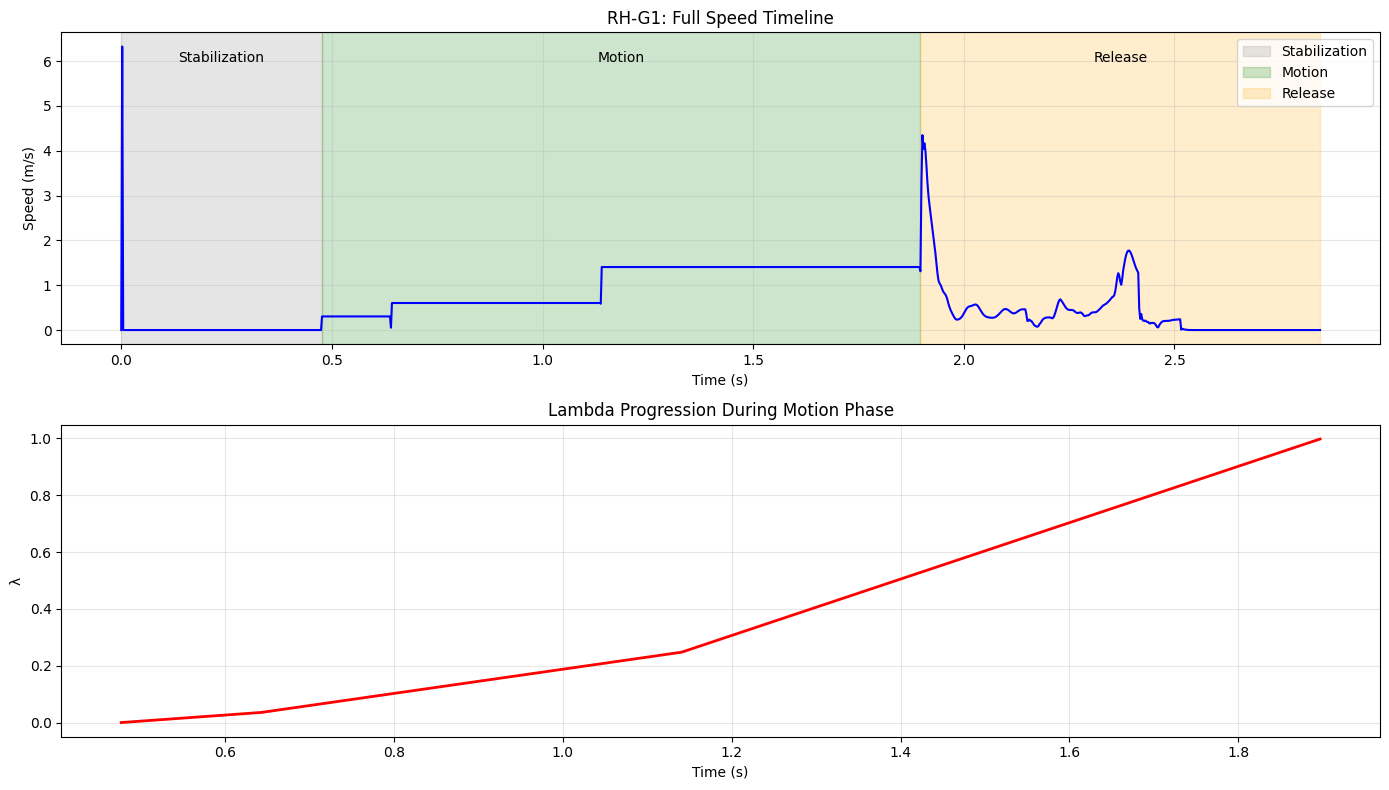

  Motion time - Actual: 1.420s, Target: 1.422s
  Motion speed plot saved to RH_G1_motion_speed_vs_time.png


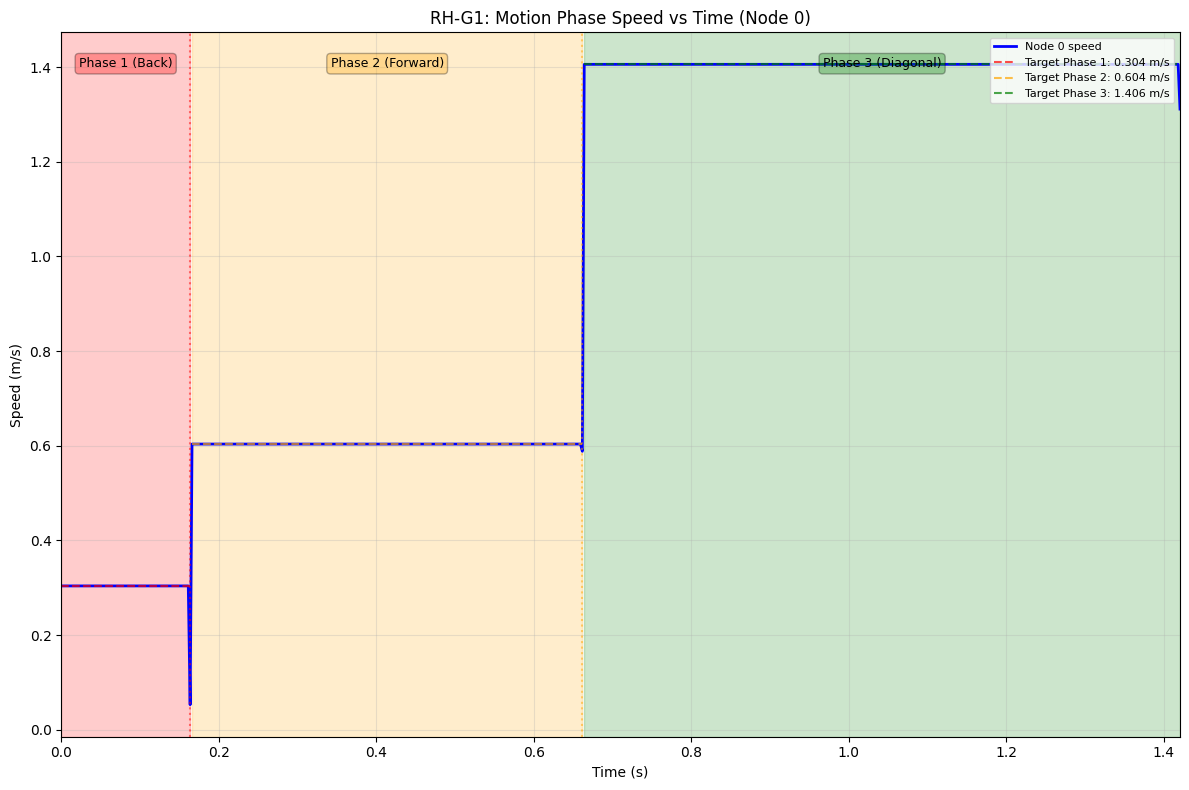

In [28]:
import pickle

#  Main execution
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    
    # Load optimization results
    with open('Optimisation_DT_wide.pkl', 'rb') as f:
        results = pickle.load(f)
    
    for (cloth_name, grasp_name), data in results.items():
        print(f"\n{'#'*80}")
        print(f"Running simulation for {cloth_name}-{grasp_name}")
        print(f"{'#'*80}")
        
        # Run simulation with corrected output
        sim_result = run_with_optimal_speeds_from_distances_times(
            data, cloth_name, grasp_name, dt=None
        )
        
        # Get controlled node indices
        X, T, na, nb = create_initial_mesh()
        inds_ctr = get_grasp_config(grasp_name, na)
        
        # Plot 1: Full timeline (shows all phases)
        plot_full_timeline(sim_result, inds_ctr, cloth_name, grasp_name,
                          save_path=f"{cloth_name}_{grasp_name}_timeline.png")
    
        # Plot 2: Motion Phase Speed vs Time (only motion, no stabilization/release)
        plot_motion_speed_vs_time(sim_result, inds_ctr, cloth_name, grasp_name,
                                  save_path=f"{cloth_name}_{grasp_name}_motion_speed_vs_time.png")
        

Plotting of the speeds with its physical sign, actual speeds in the simulator.

Distances for RH_G1: [0.05011847 0.30076509 1.06672166]
Times for RH_G1: [0.16501358 0.49835073 0.75872071]
Speeds for RH_G1: [np.float64(0.3037233305230085), np.float64(0.603520921986148), np.float64(1.4059477232090702)]

################################################################################
Running simulation for RH-G1
################################################################################
  Stabilisation phase...

Updated path geometry:
  Phase 1 (back): [0.         0.05011847 0.        ] (distance: 0.050m)
  Phase 2 (forward): [ 0.         -0.25064661  0.        ] (distance: 0.301m)
  Phase 3 (diagonal): [ 0.         -0.77313595 -0.93      ] (distance: 1.067m)
  Lambda points: ['0.0000', '0.0354', '0.2475', '1.0000']
  Motion phase: 601 positions, lambda from 0.000 to 1.000
  Motion phase...
  Release phase...
  Motion steps: 600 (should match trajectory: 601)
  Lambda steps: 601
  Motion time - Actual: 1.420s, Target: 1.422s
Figure saved as: RH_G1_motion_phases.

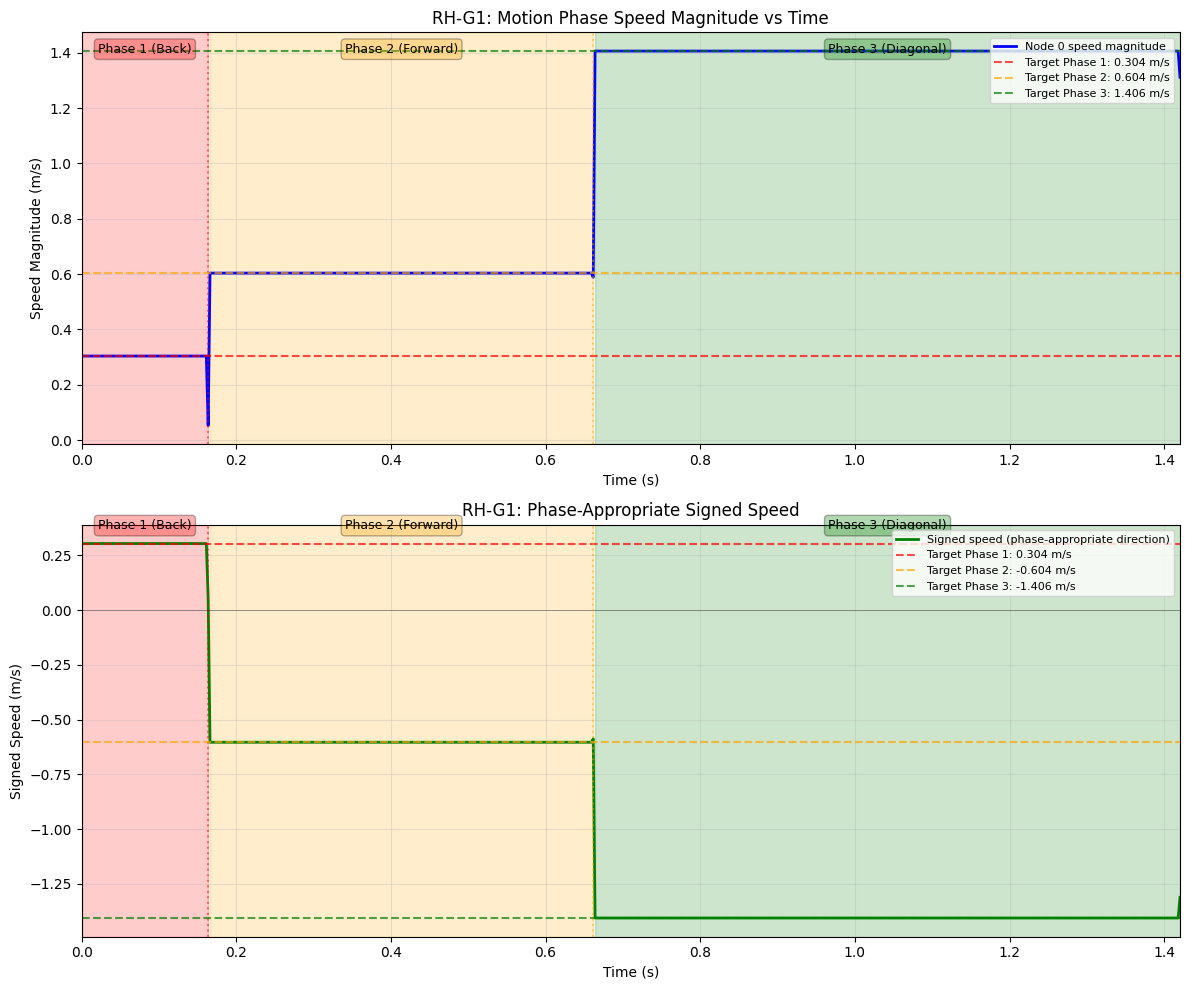

In [29]:
# Plot optimal speed profile and the actual speed profile from simulation, with phase coloring and target speed lines for each phase, 
# using the motion phase data only (no stabilization/release phases), and using PCA to determine the dominant motion direction for signed speed calculation.

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Load optimization results
with open('Optimisation_DT_wide.pkl', 'rb') as f:
    results = pickle.load(f)

for (cloth_name, grasp_name), result in results.items():
    print(f"Distances for {cloth_name}_{grasp_name}: {result['phase_distances']}")
    print(f"Times for {cloth_name}_{grasp_name}: {result['phase_times']}")
    print(f"Speeds for {cloth_name}_{grasp_name}: {result['speeds']}")

for (cloth_name, grasp_name), data in results.items():
    print(f"\n{'#'*80}")
    print(f"Running simulation for {cloth_name}-{grasp_name}")
    print(f"{'#'*80}")
    
    # Run simulation with corrected output
    sim_result = run_with_optimal_speeds_from_distances_times(
        data, cloth_name, grasp_name, dt=None)

    # Extract motion-only data
    motion_vel = sim_result['motion_history_vel']
    phase_times = sim_result['phase_times']
    phase_distances = sim_result['phase_distances']
    lam_seq = sim_result['lam_seq']
    dt = sim_result['dt']
    
    # Use first controlled node
    first_ctrl_node = 0
    
    # Get motion phase velocities only
    motion_vel_node = motion_vel[:, first_ctrl_node, :]  # (timesteps, 3)
    
    # Calculate magnitude
    speed_magnitude = np.linalg.norm(motion_vel_node, axis=1)
    
    # Find phase boundaries using lam_seq
    total_dist = sum(phase_distances)
    lam_a = phase_distances[0] / total_dist
    lam_b = (phase_distances[0] + phase_distances[1]) / total_dist
    lam_pts = [0.0, lam_a, lam_b, 1.0]
    completion = lam_seq
    
    # Find time indices for each phase
    phase_time_indices = []
    for lam_target in lam_pts[1:]:
        idx = np.searchsorted(completion, lam_target)
        phase_time_indices.append(idx)
    
    # Determine direction vectors for each phase
    # For phase 1 (Back) and phase 2 (Forward): motion is along Y-axis
    # For phase 3 (Diagonal): use PCA to find dominant direction
    
    # Extract velocities for phase 3 (diagonal phase)
    start_phase3 = phase_time_indices[1]  # Start of phase 3
    end_phase3 = phase_time_indices[2] if len(phase_time_indices) > 2 else len(motion_vel_node)
    
    # Project onto first principal component (dominant motion direction)
    phase3_velocities = motion_vel_node[start_phase3:end_phase3]
    pca = PCA(n_components=1)
    # pca.fit(motion_vel_node)
    pca.fit(phase3_velocities)
    diagonal_dir = pca.components_[0]

    # Define direction vectors for each phase
    # Assuming Y-axis is the primary axis for back/forward motion
    # Adjust sign based on expected motion direction
    # Keep original sign (either + and -), so not sign change!
    y_direction = np.array([0, 1, 0])  # Positive Y
    
    # For signed speed calculation
    signed_speed = np.zeros(len(motion_vel_node))
    
    # Phase 1: Back (negative Y direction)
    start_phase1 = 0
    end_phase1 = phase_time_indices[0]
    signed_speed[start_phase1:end_phase1] = np.dot(motion_vel_node[start_phase1:end_phase1], y_direction)
    
    # Phase 2: Forward (positive Y direction)
    start_phase2 = phase_time_indices[0]
    end_phase2 = phase_time_indices[1]
    signed_speed[start_phase2:end_phase2] = np.dot(motion_vel_node[start_phase2:end_phase2], y_direction)
    
    # Phase 3: Diagonal (along PCA direction)
    start_phase3 = phase_time_indices[1]
    end_phase3 = phase_time_indices[2] if len(phase_time_indices) > 2 else len(motion_vel_node)
    signed_speed[start_phase3:end_phase3]= np.dot(motion_vel_node[start_phase3:end_phase3], diagonal_dir)

    # Time array
    n_steps = len(speed_magnitude)
    motion_time = np.arange(n_steps) * dt
    
    # Total times
    actual_motion_time = motion_time[-1]
    target_motion_time = sum(phase_times)
    
    print(f"  Motion time - Actual: {actual_motion_time:.3f}s, Target: {target_motion_time:.3f}s")
    
    # Target speeds
    target_speeds = [phase_distances[i] / phase_times[i] for i in range(3)]
    
    # Create figure
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    colors = ['red', 'orange', 'green']
    phase_names = ['Phase 1 (Back)', 'Phase 2 (Forward)', 'Phase 3 (Diagonal)']
    
    # Plot 1: Speed Magnitude
    axes[0].plot(motion_time, speed_magnitude, 'b-', linewidth=2, label=f'Node {first_ctrl_node} speed magnitude')
    
    # Color phases for magnitude plot
    start_idx = 0
    for i in range(3):
        end_idx = phase_time_indices[i] if i < len(phase_time_indices) else len(speed_magnitude)
        
        if start_idx < end_idx:
            t_start = motion_time[start_idx]
            t_end = motion_time[end_idx - 1] if end_idx < len(motion_time) else motion_time[-1]
            
            axes[0].axvspan(t_start, t_end, alpha=0.2, color=colors[i])
            
            mid_time = (t_start + t_end) / 2
            axes[0].text(mid_time, axes[0].get_ylim()[1]*0.95, phase_names[i], 
                        ha='center', fontsize=9, 
                        bbox=dict(boxstyle="round", facecolor=colors[i], alpha=0.3))
            
            if i < 2:
                axes[0].axvline(x=t_end, color=colors[i], linestyle=':', alpha=0.5)
            
            axes[0].axhline(y=target_speeds[i], color=colors[i], linestyle='--', alpha=0.7,
                           label=f'Target Phase {i+1}: {target_speeds[i]:.3f} m/s')
        
        start_idx = end_idx
    
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Speed Magnitude (m/s)')
    axes[0].set_title(f'{cloth_name}-{grasp_name}: Motion Phase Speed Magnitude vs Time')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([0, motion_time[-1]])
    
    # Plot 2: Phase-Appropriate Signed Speed
    axes[1].plot(motion_time, signed_speed, 'g-', linewidth=2, label='Signed speed (phase-appropriate direction)')
    axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
    
    # Color phases for signed speed plot
    start_idx = 0
    for i in range(3):
        end_idx = phase_time_indices[i] if i < len(phase_time_indices) else len(signed_speed)
        
        if start_idx < end_idx:
            t_start = motion_time[start_idx]
            t_end = motion_time[end_idx - 1] if end_idx < len(motion_time) else motion_time[-1]
            
            axes[1].axvspan(t_start, t_end, alpha=0.2, color=colors[i])
            
            mid_time = (t_start + t_end) / 2
            axes[1].text(mid_time, axes[1].get_ylim()[1]*0.95, phase_names[i], 
                        ha='center', fontsize=9, 
                        bbox=dict(boxstyle="round", facecolor=colors[i], alpha=0.3))
            
            if i < 2:
                axes[1].axvline(x=t_end, color=colors[i], linestyle=':', alpha=0.5)
            
            # Target lines with appropriate signs
            if i == 0:  # Phase 1: Back (negative)
                axes[1].axhline(y=target_speeds[i], color=colors[i], linestyle='--', alpha=0.7,
                               label=f'Target Phase {i+1}: {target_speeds[i]:.3f} m/s')
            else:  # Phases 2 and 3: Forward (positive)
                axes[1].axhline(y=-target_speeds[i], color=colors[i], linestyle='--', alpha=0.7,
                               label=f'Target Phase {i+1}: {-target_speeds[i]:.3f} m/s')
        
        start_idx = end_idx
    
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Signed Speed (m/s)')
    axes[1].set_title(f'{cloth_name}-{grasp_name}: Phase-Appropriate Signed Speed')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim([0, motion_time[-1]])
    
    plt.tight_layout()

    # Save the figure
    filename = f'{cloth_name}_{grasp_name}_motion_phases.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Figure saved as: {filename}")

    plt.show()


Running opt. simulation for RH_G1
  Stabilisation phase...

Updated path geometry:
  Phase 1 (back): [0.         0.28004475 0.        ] (distance: 0.280m)
  Phase 2 (forward): [ 0.        -0.0026483  0.       ] (distance: 0.283m)
  Phase 3 (diagonal): [ 0.        -0.3862307 -0.93     ] (distance: 1.006m)
  Lambda points: ['0.0000', '0.1785', '0.3587', '1.0000']
  Motion phase: 433 positions, lambda from 0.000 to 1.000
  Motion phase...
  Release phase...
  Motion steps: 432 (should match trajectory: 433)
  Lambda steps: 433
Figure saved as: RH_G1_traj_profile.png


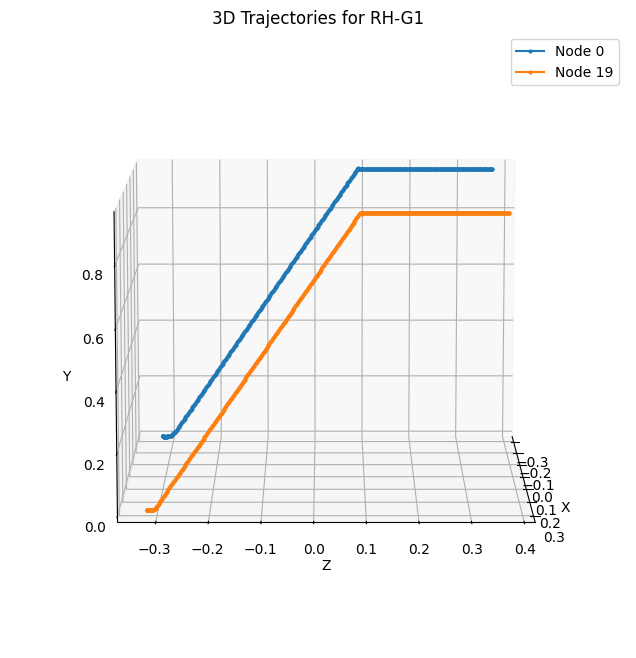

In [47]:
## Loop that re-runs experiments with new opt. speeds, which saved above in the pickle file

import itertools
import os
import polyscope as ps

with open('Optimisation_DT_narrow_alpha_0.01.pkl', 'rb') as f:
    results = pickle.load(f)
    
for _, data in results.items():

    print(f"Running opt. simulation for {cloth_name}_{grasp_name}")

    # Run simulation with corrected output
    sim_result = run_with_optimal_speeds_from_distances_times(
            data, cloth_name, grasp_name, dt=None)
    
    na = 20
    inds_ctr = get_grasp_config(grasp_name, na) # get controlled nodes

    # Plot 3D trajectory of nodes
    fig3D = plt.figure(figsize=(10, 8))
    ax = fig3D.add_subplot(111, projection='3d')

    # Camera view: adjusted to see it from the front
    ax.view_init(elev=10, azim=0)

    history_pos = sim_result['full_history_pos']  # (timesteps, num_nodes, 3)

    for node_id in inds_ctr: # plot trajectory for each selected node
        trajectory = history_pos[:, node_id, :] # get the history_pos of the nodes
        
        ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], label=f'Node {node_id}', marker='o', markersize=2) # plot XYZ given by (X, Z, Y)

    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y')
    ax.legend()
    plt.title(f'3D Trajectories for {cloth_name}-{grasp_name}')

    # Save the figure
    filename = f'{cloth_name}_{grasp_name}_traj_profile.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Figure saved as: {filename}")

    plt.show()

Trajectory visual with speed mapping

Running opt. simulation for RH_G1
  Stabilisation phase...

Updated path geometry:
  Phase 1 (back): [0.         0.31554982 0.        ] (distance: 0.316m)
  Phase 2 (forward): [0.         0.09823475 0.        ] (distance: 0.217m)
  Phase 3 (diagonal): [ 0.         -0.40137363 -0.93      ] (distance: 1.056m)
  Lambda points: ['0.0000', '0.1986', '0.3354', '1.0000']
  Motion phase: 463 positions, lambda from 0.000 to 1.000
  Motion phase...
  Release phase...
  Motion steps: 462 (should match trajectory: 463)
  Lambda steps: 463
Figure saved as: RH_G1_traj_speed_mapping_wide.png


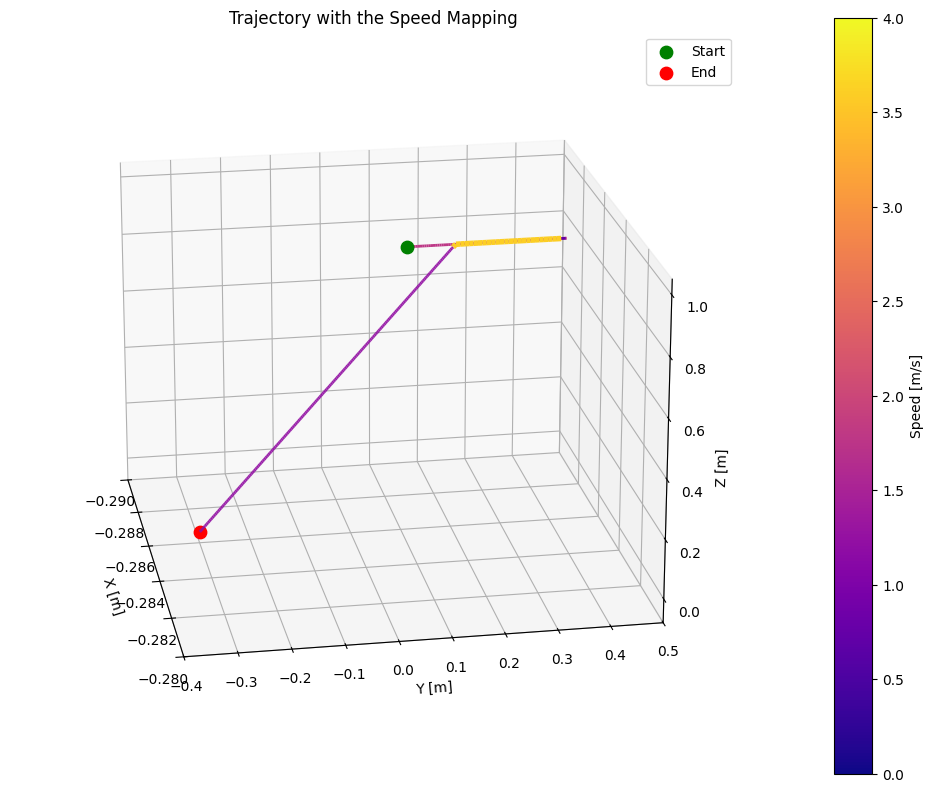

In [74]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d.art3d import Line3DCollection
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.cm as cm
import matplotlib.colors as mcolors


# ============================================================
# Load optimization results
# ============================================================

with open('Optimisation_DT_wide_alpha_0.01.pkl', 'rb') as f:
    results = pickle.load(f)

# ============================================================
# Run simulations and plot trajectories
# ============================================================

for _, data in results.items():

    print(f"Running opt. simulation for {cloth_name}_{grasp_name}")

    sim_result = run_with_optimal_speeds_from_distances_times(
        data,
        cloth_name,
        grasp_name,
        dt=None
    )

    # --------------------------------------------------------
    # Get controlled node
    # --------------------------------------------------------

    na = 20
    inds_ctr = get_grasp_config(grasp_name, na)

    node_id = inds_ctr[0]      # only first grasped node

    # --------------------------------------------------------
    # Trajectory positions
    # --------------------------------------------------------

    history_pos = sim_result['motion_history_pos']
    
    dt = sim_result.get('dt', 0.01)

    trajectory = history_pos[:, node_id, :]
    
    # --------------------------------------------------------
    # Compute speed from trajectory
    # --------------------------------------------------------
    # Target speeds
    speeds = sim_result['motion_history_vel']
    
    speed = speeds[:, node_id, :]
    speed_mag = np.linalg.norm(speed, axis=1)

    # repeat last value to keep same length
    speed_mag = np.append(speed_mag, speed_mag[-1])

    # --------------------------------------------------------
    # Build colored segments
    # --------------------------------------------------------

    points = trajectory

    segments = np.stack(
        [points[:-1], points[1:]],
        axis=1
    )

    # Common color scale
    norm = mcolors.Normalize(
        vmin=0,
        vmax=4.0
    )

    cmap = cm.plasma

    colors = cmap(norm(speed_mag[:-1]))

    linewidths = np.where(
        speed_mag[:-1] > 3.0,
        4,
        2
    )

    lc = Line3DCollection(
        segments,
        colors=colors,
        linewidth=linewidths
    )

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.add_collection3d(lc)

    # Start marker
    ax.scatter(
        trajectory[0,0],
        trajectory[0,1],
        trajectory[0,2],
        color='green',
        s=80,
        label='Start'
    )

    # End marker
    ax.scatter(
        trajectory[-1,0],
        trajectory[-1,1],
        trajectory[-1,2],
        color='red',
        s=80,
        label='End'
    )

    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm
    )

    sm.set_array([])

    fig.colorbar(
        sm,
        ax=ax,
        pad=0.1,
        label='Speed [m/s]'
    )

    # --------------------------------------------------------
    # Cosmetics
    # --------------------------------------------------------

    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')

    # Axis limits — must be set manually for Line3DCollection
    for set_lim, data in zip(
        [ax.set_xlim, ax.set_ylim, ax.set_zlim], [trajectory[:, 0], trajectory[:, 1], trajectory[:, 2]]
    ):
        pad = ((data.max() - data.min()) or 0.01) * 0.1
        set_lim(np.floor((data.min() - pad) * 100) / 100,
            np.ceil( (data.max() + pad) * 100) / 100)

    ax.set_ylim(-0.4, 0.5) 

    ax.view_init(
        elev=20,
        azim=-10
    )

    ax.legend()

    plt.title(
        f'Trajectory with the Speed Mapping'
    )

    plt.tight_layout()

    filename = (
        f'{cloth_name}_{grasp_name}_traj_speed_mapping_wide.png'
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight'
    )

    print(f"Figure saved as: {filename}")

    plt.show()

Plot lambda progression


################################################################################
Running simulation for RH-G1
################################################################################
  Stabilisation phase...

Updated path geometry:
  Phase 1 (back): [0.         0.31554982 0.        ] (distance: 0.316m)
  Phase 2 (forward): [0.         0.09823475 0.        ] (distance: 0.217m)
  Phase 3 (diagonal): [ 0.         -0.40137363 -0.93      ] (distance: 1.056m)
  Lambda points: ['0.0000', '0.1986', '0.3354', '1.0000']
  Motion phase: 463 positions, lambda from 0.000 to 1.000
  Motion phase...
  Release phase...
  Motion steps: 462 (should match trajectory: 463)
  Lambda steps: 463
Figure saved as: Lambda_progress_DT_wide.png


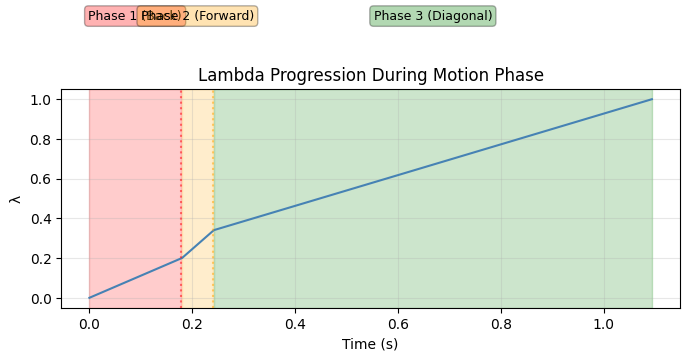

In [81]:
# Plot 2: Lambda progression (only during motion)

# Load optimization results
with open('Optimisation_DT_wide_alpha_0.01.pkl', 'rb') as f:
    results = pickle.load(f)

for (cloth_name, grasp_name), data in results.items():
    print(f"\n{'#'*80}")
    print(f"Running simulation for {cloth_name}-{grasp_name}")
    print(f"{'#'*80}")
    
    # Run simulation with corrected output
    sim_result = run_with_optimal_speeds_from_distances_times(
        data, cloth_name, grasp_name, dt=None
    )
    
    # Get controlled node indices
    X, T, na, nb = create_initial_mesh()
    inds_ctr = get_grasp_config(grasp_name, na)

    full_vel = sim_result['full_history_vel']
    motion_start = sim_result['motion_start_idx']
    motion_end = sim_result['motion_end_idx']
    dt = sim_result['dt']
    lam_seq = sim_result['lam_seq']
    phase_times = sim_result['phase_times']
    phase_distances = sim_result['phase_distances']

    motion_time = np.arange(len(lam_seq)) * dt

    # Find phase boundaries using lam_seq
    total_dist = sum(phase_distances)
    lam_a = phase_distances[0] / total_dist
    lam_b = (phase_distances[0] + phase_distances[1]) / total_dist
    lam_pts = [0.0, lam_a, lam_b, 1.0]
    completion = lam_seq

    # Find time indices for each phase
    phase_time_indices = []
    for lam_target in lam_pts[1:]:
        idx = np.searchsorted(completion, lam_target)
        phase_time_indices.append(idx)

    # create figure
    fig, ax = plt.subplots(figsize=(7,4))

    colors = ['red', 'orange', 'green']
    phase_names = ['Phase 1 (Back)', 'Phase 2 (Forward)', 'Phase 3 (Diagonal)']

    ax.plot(motion_time, lam_seq, color="steelblue", linewidth=1.5)

    # Color phases for magnitude plot
    start_idx = 0
    for i in range(3):
        end_idx = phase_time_indices[i] if i < len(phase_time_indices) else len(lam_seq)
        
        if start_idx < end_idx:
            t_start = motion_time[start_idx]
            t_end = motion_time[end_idx - 1] if end_idx < len(motion_time) else motion_time[-1]
            
            ax.axvspan(t_start, t_end, alpha=0.2, color=colors[i])
            
            mid_time = (t_start + t_end) / 2
            ax.text(mid_time, axes[0].get_ylim()[1]*0.95, phase_names[i], 
                        ha='center', fontsize=9, 
                        bbox=dict(boxstyle="round", facecolor=colors[i], alpha=0.3))
            
            if i < 2:
                ax.axvline(x=t_end, color=colors[i], linestyle=':', alpha=0.5)
            
        start_idx = end_idx
    

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('λ')
    ax.set_title('Lambda Progression During Motion Phase')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    filename = (
        f'Lambda_progress_DT_wide.png'
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight'
    )

    print(f"Figure saved as: {filename}")

    plt.show()


################################################################################
Running simulation for RH-G1
################################################################################
  Stabilisation phase...

Updated path geometry:
  Phase 1 (back): [0.         0.28004475 0.        ] (distance: 0.280m)
  Phase 2 (forward): [ 0.        -0.0026483  0.       ] (distance: 0.283m)
  Phase 3 (diagonal): [ 0.        -0.3862307 -0.93     ] (distance: 1.006m)
  Lambda points: ['0.0000', '0.1785', '0.3587', '1.0000']
  Motion phase: 433 positions, lambda from 0.000 to 1.000
  Motion phase...
  Release phase...
  Motion steps: 432 (should match trajectory: 433)
  Lambda steps: 433
Figure saved as: Lambda_progress_DT_narrow.png


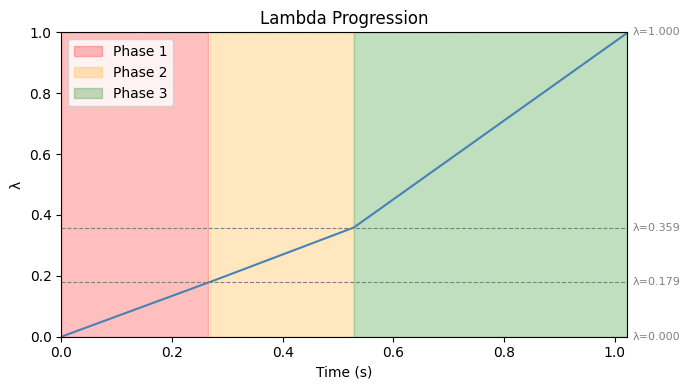

In [87]:
# Plot 2: Lambda progression (only during motion)

# Load optimization results
with open('Optimisation_DT_narrow_alpha_0.01.pkl', 'rb') as f:
    results = pickle.load(f)

for (cloth_name, grasp_name), data in results.items():
    print(f"\n{'#'*80}")
    print(f"Running simulation for {cloth_name}-{grasp_name}")
    print(f"{'#'*80}")
    
    # Run simulation with corrected output
    sim_result = run_with_optimal_speeds_from_distances_times(
        data, cloth_name, grasp_name, dt=None
    )
    
    # Get controlled node indices
    X, T, na, nb = create_initial_mesh()
    inds_ctr = get_grasp_config(grasp_name, na)

    full_vel = sim_result['full_history_vel']
    motion_start = sim_result['motion_start_idx']
    motion_end = sim_result['motion_end_idx']
    dt = sim_result['dt']
    lam_seq = sim_result['lam_seq']
    phase_times = sim_result['phase_times']
    phase_distances = sim_result['phase_distances']

    motion_time = np.arange(len(lam_seq)) * dt

    # lam_knots
    total_d = sum(phase_distances)
    lam_a = phase_distances[0] / total_d
    lam_b = (phase_distances[0] + phase_distances[1]) / total_d
    lam_knots = [0, lam_a, lam_b, 1]

    # create figure
    fig, ax = plt.subplots(figsize=(7,4))

    colors = ['red', 'orange', 'green']
    phase_names = ['Phase 1 (Back)', 'Phase 2 (Forward)', 'Phase 3 (Diagonal)']

    ax.plot(motion_time, lam_seq, color="steelblue", linewidth=1.5)

    # Phase transition lines
    for i, lk in enumerate(lam_knots):
        ax.axhline(lk, color="gray", linestyle="--", linewidth=0.8)
        ax.text(motion_time[-1] * 1.01, lk, f"λ={lk:.3f}", fontsize=8,
                color="gray", va="center")
        
    boundaries = [0, lam_knots[1], lam_knots[2], 1.0]
    for i in range(3):
        # find time where lam crosses each boundary
        t_start = motion_time[np.searchsorted(lam_seq, boundaries[i])]
        t_end   = motion_time[np.searchsorted(lam_seq, boundaries[i+1]) - 1]
        ax.axvspan(t_start, t_end, color=colors[i], alpha=0.25,
                   label=f"Phase {i+1}")
    
    ax.legend(loc="upper left")
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('λ')
    ax.set_ylim(0, 1)
    ax.set_xlim(motion_time[0], motion_time[-1])
    ax.set_title('Lambda Progression')

    plt.tight_layout()

    filename = (
        f'Lambda_progress_DT_narrow.png'
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight'
    )

    print(f"Figure saved as: {filename}")

    plt.show()

Plots of contributions for each experiment

Figure saved as: Norm_dist_contr_DT.png


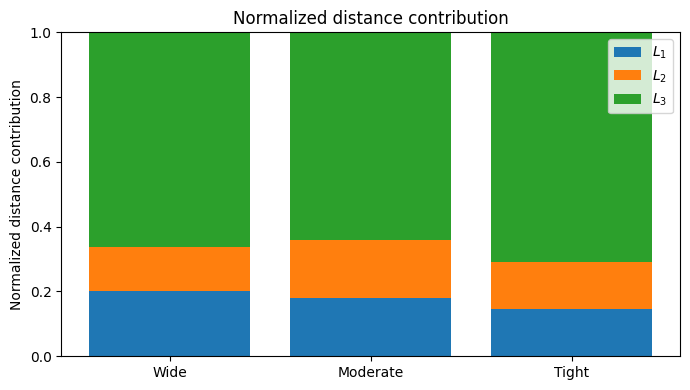

In [71]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["Wide", "Moderate", "Tight"]

distances = np.array([
    [0.32, 0.22, 1.06],
    [0.28, 0.28, 1.00],
    [0.20, 0.20, 0.98]
])

dist_norm = distances / distances.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7,4))

bottom = np.zeros(len(labels))

for i, phase in enumerate(["$L_1$","$L_2$","$L_3$"]):
    ax.bar(
        labels,
        dist_norm[:,i],
        bottom=bottom,
        label=phase
    )
    bottom += dist_norm[:,i]

ax.set_ylabel("Normalized distance contribution")
ax.set_ylim([0,1])
plt.title("Normalized distance contribution")
ax.legend()

plt.tight_layout()

filename = (
    f'Norm_dist_contr_DT.png'
)

plt.savefig(
    filename,
    dpi=300,
    bbox_inches='tight'
)

print(f"Figure saved as: {filename}")

plt.show()

Convert lambda speeds to time per phase: lambda/s to m/s through *1.7 (total distance: 1 lambda = 1.7 m), and divide eachcorresponding phase distance by the speed to have time for each phase.

In [110]:
# Speed optimization - Baseline
L1 = 0.2
L2 = 0.4
L3 = 1.1

[L1/(1.52*1.7), L2/(0.91*1.7), L3/(0.81*1.7)]
[L1/(0.73*1.7), L2/(0.65*1.7), L3/(1.12*1.7)]
[L1/(0.65*1.7), L2/(0.67*1.7), L3/(1.12*1.7)]
[L1/(1.02*1.7), L2/(0.61*1.7), L3/(1.15*1.7)]

# Speed optimization - Human
L1 = 0.2
L2 = 0.1
L3 = 1.1

[L1/(0.27*1.4), L2/(2.07*1.4), L3/(1.34*1.4)]
[L1/(0.3*1.4), L2/(1.3*1.4), L3/(1.55*1.4)]
[L1/(1.08*1.4), L2/(0.13*1.4), L3/(1.66*1.4)]
[L1/(0.43*1.4), L2/(1.85*1.4), L3/(1.77*1.4)]




[0.33222591362126247, 0.038610038610038616, 0.443906376109766]

Plot time contribution, not normalized, for all experiments

Figure saved as: Norm_time_contr_DT.png


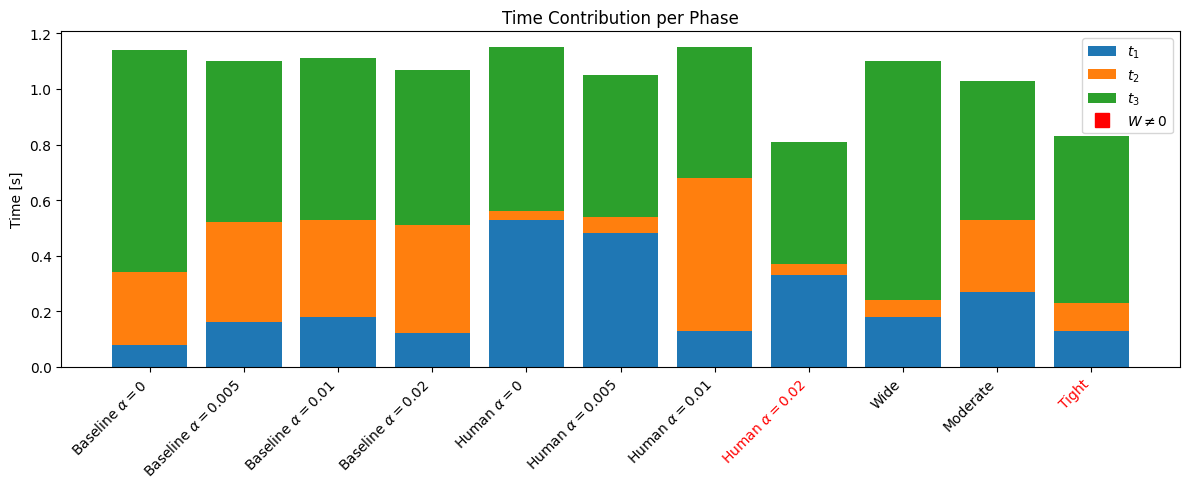

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

times = np.array([
    # Speed optimization - Baseline
    [0.08, 0.26, 0.8],
    [0.16, 0.36, 0.58],
    [0.18, 0.35, 0.58],
    [0.12, 0.39, 0.56],
    
    # Speed optimization - Human
    [0.53, 0.03, 0.59],
    [0.48, 0.06, 0.51],
    [0.13, 0.55, 0.47],
    [0.33, 0.04, 0.44],
    
    # Distance + Time optimization
    [0.18, 0.06, 0.86],
    [0.27, 0.26, 0.50],
    [0.13, 0.10, 0.60]
])


fig, ax = plt.subplots(figsize=(12, 5))

labels = [r"Baseline $\alpha = 0$", r"Baseline $\alpha = 0.005$", r"Baseline $\alpha = 0.01$", r"Baseline $\alpha = 0.02$",
          r"Human $\alpha = 0$", r"Human $\alpha = 0.005$", r"Human $\alpha = 0.01$", r"Human $\alpha = 0.02$",
           "Wide", "Moderate", "Tight"]

bottom = np.zeros(len(labels))

for i, phase in enumerate(["$t_1$", "$t_2$", "$t_3$"]):
    ax.bar(
        labels,
        times[:, i],
        bottom=bottom,
        label=phase
    )
    bottom += times[:, i]

ax.set_ylabel("Time [s]")
ax.set_title("Time Contribution per Phase")

# Existing legend handles
handles, labels_legend = ax.get_legend_handles_labels()

# Custom entry for red labels
red_label = Line2D(
    [0], [0],
    color='red',
    lw=0,
    marker='s',
    markersize=10,
    label=r'$W \neq 0$'
)

handles.append(red_label)

ax.legend(handles=handles)

plt.xticks(rotation=45, ha='right')

# Color labels red if the total stacked height is < 1.0
totals = times.sum(axis=1)

for tick, total in zip(ax.get_xticklabels(), totals):
    if total < 1.0:
        tick.set_color('red')

plt.tight_layout()

filename = 'Norm_time_contr_DT.png'

plt.savefig(
    filename,
    dpi=300,
    bbox_inches='tight'
)

print(f"Figure saved as: {filename}")

plt.show()



Figure saved as: Norm_speed_contr_DT.png


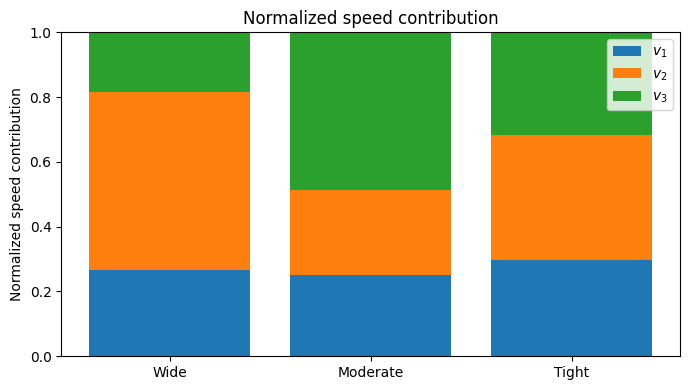

In [73]:
speeds = distances/times

speed_norm = speeds / speeds.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7,4))

bottom = np.zeros(len(labels))

for i, phase in enumerate(["$v_1$","$v_2$","$v_3$"]):
    ax.bar(
        labels,
        speed_norm[:,i],
        bottom=bottom,
        label=phase
    )
    bottom += speed_norm[:,i]

ax.set_ylabel("Normalized speed contribution")
ax.set_ylim([0,1])
ax.set_title("Normalized speed contribution")
ax.legend()

plt.tight_layout()

filename = (
    f'Norm_speed_contr_DT.png'
)

plt.savefig(
    filename,
    dpi=300,
    bbox_inches='tight'
)

print(f"Figure saved as: {filename}")

plt.show()

Saving videos. Frames folder is deleted after generating the video.

In [26]:
# Function to save frames
import polyscope as ps
import os
import numpy as np

def save_frames_ps(history_pos, Am, label, folder="frames", step=4):
    os.makedirs(folder, exist_ok=True)
    n_frames = len(history_pos)
    print(f"Saving {n_frames//step} frames to {folder}/")

    for i, frame_idx in enumerate(range(0, n_frames, step)):
        phi_mat = history_pos[frame_idx]
        phi_all = Am @ phi_mat

        ps.get_surface_mesh(label).update_vertex_positions(phi_all)
        ps.screenshot(os.path.join(folder, f"frame_{i:04d}.png"), transparent_bg=False)


        if i % 50 == 0:
            print(f"Saved frame {i} / {n_frames//step}")

In [27]:
#  Function to save video from frames folder

import subprocess
import shutil

def create_video_from_frames(frames_folder, output_video, framerate=20, cleanup = True):
    """
    Create a video from a sequence of frames using ffmpeg.
    
    Args:
        frames_folder: Path to folder containing frame_XXXX.png files
        output_video: Output video filename (e.g., "experiment.mp4")
        framerate: Framerate for the video (default: 20)
        cleanup: If True, delete the frames folder after video creation (default: True)
    """
    try:
        cmd = [
            "ffmpeg",
            "-framerate", str(framerate),
            "-i", f"{frames_folder}/frame_%04d.png",
            "-vf", "scale=trunc(iw/2)*2:trunc(ih/2)*2",
            "-c:v", "libx264",
            "-pix_fmt", "yuv420p",
            "-y",  # overwrite output file without asking
            output_video
        ]
        subprocess.run(cmd, check=True, capture_output=True)
        print(f"Video saved: {output_video}")

        # Clean up frames folder if requested
        if cleanup:
            shutil.rmtree(frames_folder)
            print(f"Removed frames folder: {frames_folder}")

    except subprocess.CalledProcessError as e:
        print(f"Error creating video: {e.stderr.decode()}")
    except FileNotFoundError:
        print("ffmpeg not found. Install it using: brew install ffmpeg")
    except Exception as e:
        print(f"Error during cleanup: {e}")

In [ ]:
import pickle

# Main execution for video generation
if __name__ == "__main__":
    # Load optimization results
    with open('Optimisation_DT_restricted_alpha_0.01.pkl', 'rb') as f:
        results = pickle.load(f)
    
    for (cloth_name, grasp_name), data in results.items():
        print(f"\n{'#'*80}")
        print(f"Running simulation for {cloth_name}-{grasp_name}")
        print(f"{'#'*80}")
        
        # Run simulation with corrected output
        sim_result = run_with_optimal_speeds_from_distances_times(
            data, cloth_name, grasp_name, dt=None
        )
        
        # Get controlled node indices
        X, T, na, nb = create_initial_mesh()
        inds_ctr = get_grasp_config(grasp_name, na)

        # Save frames and create video
        frames_folder = f"frames_{cloth_name}_{grasp_name}_Opt_Dist"
        os.makedirs(frames_folder, exist_ok=True)
        
        # Fix camera once per experiment
        ps.reset_camera_to_home_view()
        ps.set_view_projection_mode("perspective")
        ps.set_window_size(1500, 1000)

        intrinsics = ps.CameraIntrinsics(fov_vertical_deg=45., fov_horizontal_deg=45.)

        angle = np.radians(120)
        radius = 3.0
        height = 1.75

        # Compute camera position
        cam_x = radius * np.sin(angle)   # horizontal offset
        cam_z = height                    # vertical offset (low, close to table)
        cam_y = radius * np.cos(angle)    # forward/back offset

        # Look at origin
        look_dir = (-cam_x, -cam_y, -cam_z+0.3)
        up_dir = (0, 0, 1) # with the mesh rotated, now the Y-axis is the original Z-axis, so we set up to be along global Z


        extrinsics = ps.CameraExtrinsics(root=(cam_x, cam_y, cam_z), look_dir=look_dir, up_dir=up_dir)

        ps.set_view_camera_parameters(ps.CameraParameters(intrinsics, extrinsics))

        # edges configuration
        label = sim_result['label']
        mesh = ps.get_surface_mesh(label)

        mesh.set_color((0.2, 0.5, 0.8)) # RGB color of the mesh, blue for all meshes/cases (if not determined, each mesh for each new experiment will have different colors when polyscope registers them)
        mesh.set_edge_color((0.0, 0.0, 0.0))  # RGB color of the edges, black for edges
        mesh.set_edge_width(0.9)             # thickness of the edges
        
        save_frames_ps(sim_result['full_history_pos'], sim_result['Am'], 
                      sim_result['label'], folder=frames_folder, step=4)
        create_video_from_frames(frames_folder, f"{cloth_name}_{grasp_name}_DT_Restricted_alpha_0.01.mp4", cleanup=True)


################################################################################
Running simulation for RH-G1
################################################################################
  Stabilisation phase...

Updated path geometry:
  Phase 1 (back): [0.        0.1983857 0.       ] (distance: 0.198m)
  Phase 2 (forward): [ 0.         -0.00157143  0.        ] (distance: 0.200m)
  Phase 3 (diagonal): [ 0.         -0.31049038 -0.93      ] (distance: 0.980m)
  Lambda points: ['0.0000', '0.1439', '0.2890', '1.0000']
  Motion phase: 349 positions, lambda from 0.000 to 1.000
  Motion phase...
  Release phase...
  Motion steps: 348 (should match trajectory: 349)
  Lambda steps: 349
Saving 237 frames to frames_RH_G1_Opt_Dist/
Saved frame 0 / 237
Saved frame 50 / 237
Saved frame 100 / 237
Saved frame 150 / 237
Saved frame 200 / 237
Video saved: RH_G1_DT_Restricted_alpha_0.01.mp4
Removed frames folder: frames_RH_G1_Opt_Dist


: 

--------------------------------------------------------------------

#### Code to skip any combination that already exists in the pickle, and add more missing experiments without redoing it all

It loads the current dictionary, runs the new optimisations, adds the new entries, and saves the updated dictionary back to the same file.

In [ ]:
import pickle

# 1. Load existing results
try:
    with open('Optimisation_results.pkl', 'rb') as f:
        results_opt = pickle.load(f)
    print(f"Loaded {len(results_opt)} existing results.")
except FileNotFoundError:
    results_opt = {}
    print("No existing file found, starting fresh.")

# 2. Define the new cloth(s) and grasps
cloth_list_missing = ["EL"]   # only the missing ones
grasp_list = ["G1", "G2", "G3", "G4", "G5", "G6"]

# 3. Run optimizations for new combinations
for cloth_name in cloth_list_missing:
    for grasp_name in grasp_list:
        # Skip if already present (optional, prevents re-running)
        if (cloth_name, grasp_name) in results_opt:
            print(f"Skipping {cloth_name}-{grasp_name} (already in results).")
            continue
        
        print(f"\nOptimising {cloth_name}-{grasp_name}")
        best_speeds, best_cost, dt, seed, evolution = optimize_grasp_cloth(cloth_name, grasp_name, seed = 10)
        
        results_opt[(cloth_name, grasp_name)] = {
            'speeds': best_speeds,
            'objective value': best_cost,
            'dt': dt,
            'lam_knots': lam_knots,
            'seed': seed,
            'evolution': evolution}

# 4. Save the updated dictionary
with open('Optimisation_results.pkl', 'wb') as f:
    pickle.dump(results_opt, f)
    print(f"Saved {len(results_opt)} total results.")

Loaded 24 existing results.

Optimising EL-G1
Based on your mesh, your best dt is: 0.002371335656962282
EL_G1: dt=0.00237, avg_speed=1.016
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      8 0.000000000000000e+00 1.0e+00 4.31e-01  4e-01  4e-01 1:04.6
    2     16 0.000000000000000e+00 1.0e+00 3.93e-01  3e-01  4e-01 2:13.8
    3     24 1.439724552264522e-04 1.0e+00 3.72e-01  3e-01  4e-01 3:19.1
    4     32 0.000000000000000e+00 1.0e+00 4.67e-01  3e-01  6e-01 4:20.1
    5     40 5.923675585728861e-05 1.0e+00 4.30e-01  3e-01  5e-01 5:23.0
    6     48 4.781915370593618e-06 1.0e+00 3.52e-01  2e-01  4e-01 6:29.3
    7     56 0.000000000000000e+00 1.0e+00 2.82e-01  1e-01  3e-01 7:31.4
    8     64 0.000000000000000e+00 1.0e+00 2.49e-01  1e-01  3e-01 8:35.3
    9     72 0.000000000000000e+00 1.0e+00 2.75e-01  1e-01  3e-01 9:36.8
   10     80 0.000000000000000e+00 1.0e+00 2.64e-01  1e-01  3e-01 10:33.8
   11     88 0.000000000000000e+00 1.0e+00 2.33e-01  1e-01

#### Plotting for analysis / summary

----------------------------------------------------

In [ ]:
import numpy as np

# Dominant direction (e.g., mostly upward/right)
dominant_dir = np.array([0.01, 0.83, 0.56])

# Case 1: Moving along dominant direction
v1 = np.array([0, 40, 0])  # similar proportions
result1 = np.dot(v1, dominant_dir)  # POSITIVE

# Case 2: Moving opposite direction  
v2 = np.array([0, -40, 0])  # negative components
result2 = np.dot(v2, dominant_dir)  # NEGATIVE

# Case 3: Moving perpendicular
v3 = np.array([0, -1, -1.5])  # roughly perpendicular
result3 = np.dot(v3, dominant_dir)  # near ZERO

print(f"Along: {result1:.2f}")    # Positive
print(f"Opposite: {result2:.2f}") # Negative  
print(f"Perpendicular: {result3:.2f}") # Near 0

Along: 33.20
Opposite: -33.20
Perpendicular: -1.67


-------------------------------

### Report Visuals


Plot Trajectory Parametrization

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_mesh_with_grasp_and_traj(X, T, inds_ctr, lam_a, lam_b, d=0.1, theta_deg=45, title="Mesh"):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # --- Mesh ---
    triangles = X[T]
    mesh = Poly3DCollection(triangles, alpha=0.45, zorder=1)
    mesh.set_facecolor('lightblue')
    mesh.set_edgecolor('none')
    mesh.set_linewidth(0.3)
    ax.add_collection3d(mesh)

    inds_ctr = [inds_ctr[0]]
    
    # --- Offset grasp points (visibility fix) ---
    offset = -0.01
    X_offset = X.copy()
    X_offset[inds_ctr, 1] += offset  # along Z
    
    ax.scatter(
        X_offset[inds_ctr, 0],
        X_offset[inds_ctr, 1],
        X_offset[inds_ctr, 2],
        color='red',
        s=10,
        depthshade=False
    )
    
    # =========================
    # 🚀 TRAJECTORIES (ALL NODES)
    # =========================
    
    theta = np.radians(theta_deg)
    
    dir_z = np.array([0.0, 1.0, 0.0])   # back-forth (Z)
    dir_y = np.array([0.0, 0.0, 1.0])  # down (Y)
    
    table_y = np.min(X[:,2])

    label_idx = inds_ctr[0]
    
    for idx in inds_ctr:
        p0 = X[idx].copy()
        
        # 1. backward
        p1 = p0 - d * dir_z
        
        # 2. forward
        p2 = p1 + d/3 * dir_z 
        
        # 3. diagonal down
        h = p2[2] - table_y
        dz = 1 / np.tan(theta)
        dy = -h
        
        p3 = p2 + dz * dir_z + dy * dir_y
        
        # Apply same offset for visibility
        p0[1] += offset
        p1[1] += offset
        p2[1] += offset
        p3[1] += offset
        
        # --- Plot each phase with different color ---
        
        # Backward (red)
        ax.plot(
            [p0[0], p1[0]],
            [p0[1], p1[1]],
            [p0[2], p1[2]],
            color='red',
            linewidth=2.5
        )
        
        # Forward (green)
        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            [p1[2], p2[2]],
            color='green',
            linewidth=1
        )
        
        # Downward diagonal (blue)
        ax.plot(
            [p2[0], p3[0]],
            [p2[1], p3[1]],
            [p2[2], p3[2]],
            color='blue',
            linewidth=1
        )

        if idx == label_idx:
            # ----------------------------
            # Lambda knot labels
            # ----------------------------
            ax.text(
                p0[0],
                p0[1]+0.02,
                p0[2]+0.04,
                r'$\lambda = 0$',
                fontsize=11
            )

            ax.text(
                p1[0],
                p1[1]+0.03,
                p1[2]+0.05,
                fr'$\lambda_a$ = {lam_a:.2f}',
                fontsize=11
            )

            ax.text(
                p2[0],
                p2[1]+0.08,
                p2[2]+0.04,
                fr'$\lambda_b$ = {lam_b:.2f}',
                fontsize=11
            )

            ax.text(
                p3[0],
                p3[1]-0.02,
                p3[2],
                r'$\lambda = 1$',
                fontsize=11
            )

            # ----------------------------
            # Lambda knot points
            # ----------------------------
            lambda_points = np.array([p0, p1, p2, p3])

            ax.scatter(
            lambda_points[:,0],
            lambda_points[:,1],
            lambda_points[:,2],
            facecolors='white',
            edgecolors='black',
            s=60,
            linewidths=1.5,
            depthshade=False,
            zorder=10)

    # --- Formatting ---
    ax.view_init(elev=10, azim=180)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y')
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.grid(False)

    ax.plot([], [], [], color='red', label='$L_1$')
    ax.plot([], [], [], color='green', label='$L_2$')
    ax.plot([], [], [], color='blue', label='$L_3$')
    ax.legend()
    
    ax.set_title(title)
    plt.show()

    return fig

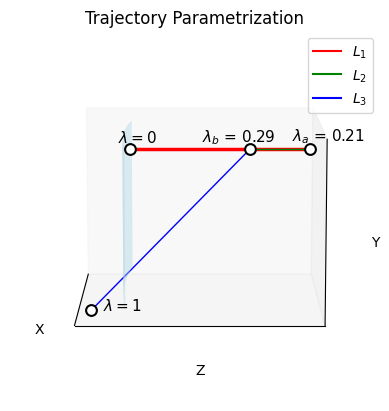

In [12]:
# apply this in function!!
L1 = 0.3
L2 = 0.1
L3 = 1

lam_a = L1/(L1+L2+L3)
lam_b = (L1+L2)/(L1+L2+L3)

X, T, na, nb = create_initial_mesh()

grasp_list = ["G1"] # only G1 for trajectory plotting

for grasp_name in grasp_list:
    inds_ctr = get_grasp_config(grasp_name, na)
    
    fig = plot_mesh_with_grasp_and_traj(
    X, T, inds_ctr, lam_a, lam_b,
    d=0.3,
    theta_deg=75,
    title="Trajectory Parametrization")

    name = "Traj_Param_DTOpt.png"
    fig.savefig(name, dpi=300, bbox_inches='tight')

Plot Lambda Progression Representation

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_lambda_progression_example(lam_a, lam_b):

    # ---------------------------------
    # Construct illustrative lambda(t)
    # ---------------------------------

    # Phase 1: slow
    t1 = np.linspace(0, 1.5, 80)
    lam1 = np.linspace(0, lam_a, len(t1))

    # Phase 2: very fast
    t2 = np.linspace(t1[-1], 2.0, 25)
    lam2 = np.linspace(lam_a, lam_b, len(t2))

    # Phase 3: much slower
    t3 = np.linspace(t2[-1], 3.0, 140)
    lam3 = np.linspace(lam_b, 1.0, len(t3))

    # Combine
    time = np.concatenate([t1, t2[1:], t3[1:]])
    lam_seq = np.concatenate([lam1, lam2[1:], lam3[1:]])

    # ---------------------------------
    # Plot
    # ---------------------------------

    fig, ax = plt.subplots(figsize=(8,4))

    ax.plot(
        time,
        lam_seq,
        linewidth=2.5,
        color='black'
    )

    # ---------------------------------
    # Phase background shading
    # ---------------------------------

    ax.axvspan(0, 1.5, color='red', alpha=0.08, label='Phase 1')
    ax.axvspan(1.5, 2.0, color='green', alpha=0.08, label='Phase 2')
    ax.axvspan(2.0, 3.0, color='blue', alpha=0.08, label='Phase 3')

    # ---------------------------------
    # Vertical phase boundaries
    # ---------------------------------

    ax.axvline(1.5, color='red', linestyle='--', alpha=0.5)
    ax.axvline(2.0, color='green', linestyle='--', alpha=0.5)

    # ---------------------------------
    # Phase boundaries
    # ---------------------------------

    ax.axhline(
        lam_a,
        color='orange',
        linestyle='--',
        alpha=0.8
    )

    ax.axhline(
        lam_b,
        color='purple',
        linestyle='--',
        alpha=0.8
    )

    # ---------------------------------
    # Labels
    # ---------------------------------

    ax.text(
        0.1,
        lam_a + 0.02,
        fr'$\lambda_a$ = {lam_a:.2f}',
        color='orange',
        fontsize=11
    )

    ax.text(
        0.1,
        lam_b + 0.02,
        fr'$\lambda_b$ = {lam_b:.2f}',
        color='purple',
        fontsize=11
    )

    # ---------------------------------
    # Optional phase labels
    # ---------------------------------

    ax.text(
        0.2,
        lam_a/2,
        'Phase 1',
        fontsize=10
    )

    ax.text(
        1.7,
        (lam_a + lam_b)/2-0.08,
        'Phase 2',
        fontsize=10
    )

    ax.text(
        2.6,
        (lam_b + 1.0)/2,
        'Phase 3',
        fontsize=10
    )

    # ---------------------------------
    # Formatting
    # ---------------------------------

    ax.set_xlabel('Time [s]')
    ax.set_ylabel(r'Path progression $\lambda$')

    ax.set_xlim(0, 3.0)
    ax.set_ylim(0, 1.05)

    ax.grid(True, alpha=0.3)

    ax.set_title(
        'Illustrative progression along the normalized trajectory path'
    )

    plt.tight_layout()
    plt.show()

    return fig

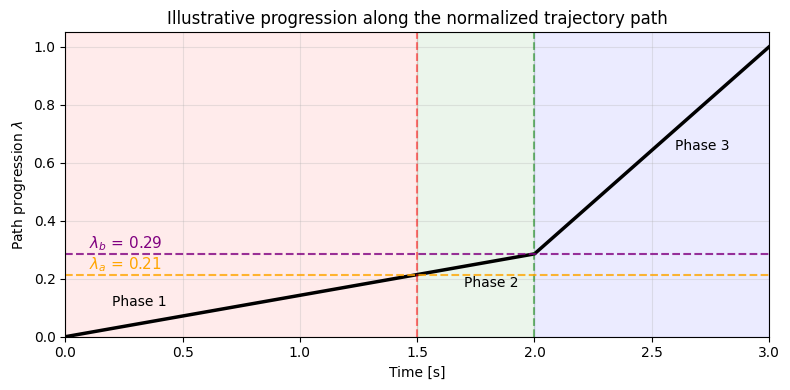

In [14]:
L1 = 0.3
L2 = 0.1
L3 = 1

lam_a = L1/(L1+L2+L3)
lam_b = (L1+L2)/(L1+L2+L3)
fig = plot_lambda_progression_example(lam_a, lam_b)

name = "LamProgress_Repr_DTOpt.png"
fig.savefig(name, dpi=300, bbox_inches='tight')